In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax.numpy as jnp
from sklearn.cluster import DBSCAN
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation, FFMpegWriter

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon
import csv

X_first: (520025, 3)
X_last: (520033, 3)
time_idx_first: (520025,)
time_idx_last: (520033,)
segments first: 1580
segments last: 2843
Measurement noise trace: -0.032397061586380005.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.032397061586380005). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 0.64821386  0.00326848 -0.01195333]
 [ 0.00326848  1.0075434   0.27053592]
 [-0.01195333  0.27053592  1.038522  ]]
Measurement noise tensor:
 [[-9.4361687e-03 -9.0120542e-05  5.9764880e-05]
 [-9.0120549e-05 -1.1390285e-02 -2.5268351e-03]
 [ 5.9764880e-05 -2.5268351e-03 -1.1570606e-02]]
Force estimated information: 104988.5390625
Force: estimated normalized mean squared error (sampling only): 0.0131633710116148
Force model:
 +26.44 (±0.5773) b₀ -17.6 (±0.1725) b₁ +10.68 (±0.06104) b₂ +0.1116 (±0.03642) b₃ -5.991 (±0.08165) b₄ +0.0148 (±0.08745) b₅ +1.74 (±0.089) b₆ +0.9267 (±0.09579) b₇ -0.3617 (±0.1024) b₈ -0.4856 (±0.

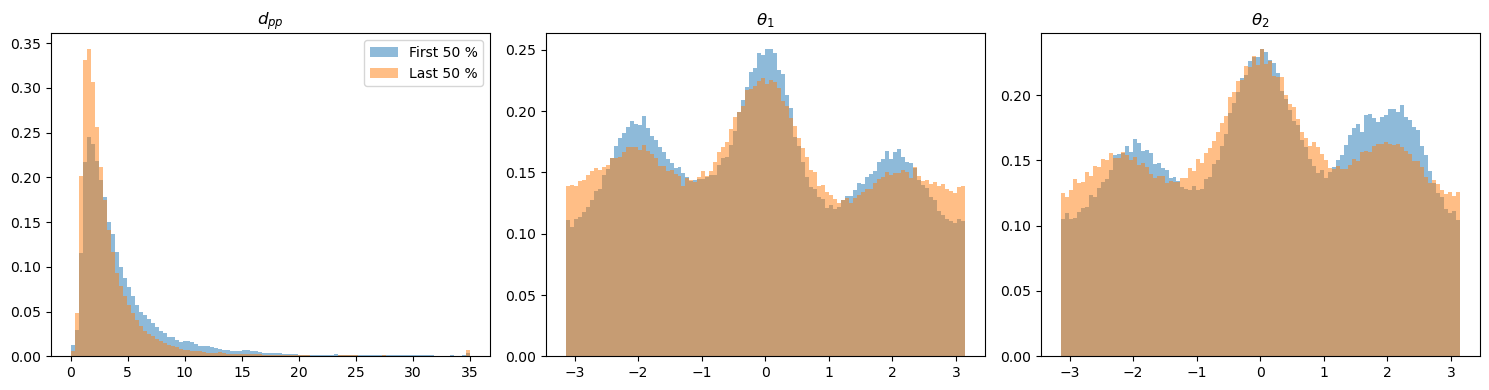

0.09704024341113353
0.09771108869851196


In [95]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon
import csv

def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info_noDurThresh"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]


    return expIdx, fightbouts
#EXP_id , fightbout = get_experimentID_fightbouts( "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200213_154940_tracking_results.h5")

def prepare_data(path,fightnumber = 0,infight =True):
    "Prepare the data make it ready to calculate dpp,theta1 and theta2"
    "if infight = True return data with only the frist infight bouts otherwise it returns total trajectory  "

    path = path
    f = h5py.File(path, "r")

    X = f["tracks_3D_smooth"][:]
    EXP_id , fightbout = get_experimentID_fightbouts(path)
    if infight == True and fightbout.size > 0:
        X_coordinates = X[fightbout[fightnumber,1]:fightbout[fightnumber,2],:,:,:]
    else:
        X_coordinates = X.copy()
    return X_coordinates,fightbout[fightnumber], EXP_id


def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def calculate_theta(fish0,fish1):
    vector_fish0 = (fish0[:,0,:] - fish0[:,1,:]) # difference in heading of head and pec
    orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

    theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])

    r_01 = fish1[:,1,:] - fish0[:,1,:] 
    phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

    theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
    psi_01 = phi_01 - theta0
    psi_01 = wrap_pi(psi_01) # wrap interval from -pi to pi
    return psi_01

def calculate_variables(coordinates_cleaned):
    "input are the coordinates and returns dpp,theta_i and theta_j"

    fish_i = coordinates_cleaned[:,0,:,:]
    fish_j = coordinates_cleaned[:,1,:,:]

    pec_fish_i = coordinates_cleaned[:,0,1,:]
    pec_fish_j = coordinates_cleaned[:,1,1,:]

    d_pp = np.linalg.norm((pec_fish_j-pec_fish_i), axis=1) 
    
    theta_i = calculate_theta(fish_i,fish_j)
    theta_j = calculate_theta(fish_j,fish_i)

    return d_pp, theta_i,theta_j
    
def clean_data(d_pp,theta_i,theta_j):
    mask = (np.isfinite(d_pp) &np.isfinite(theta_i) & np.isfinite(theta_j))
    return d_pp[mask],theta_i[mask],theta_j[mask]


def Build_segmented_data(dpp,theta1,theta2):
    Valid = (np.isfinite(dpp) &np.isfinite(theta1) & np.isfinite(theta2))
    valid_idx = np.where(Valid)[0]

    X_list = []
    time_list = []
    segid_list = []
    seg_ranges = []
    start = 0
    t_offset = 0
    seg_id = 0

    for k in range(1, len(valid_idx) + 1):
        if k == len(valid_idx) or valid_idx[k] != valid_idx[k - 1] + 1: # if there is the end of trajectory or a hole 

            seg_idx = valid_idx[start:k]

            if len(seg_idx) > 5:
                D_seg = dpp[seg_idx]
                th1_seg = np.unwrap(theta1[seg_idx])
                th2_seg = np.unwrap(theta2[seg_idx])

                X_list.append(np.column_stack([D_seg, th1_seg, th2_seg]))
                time_list.append(np.arange(len(seg_idx)) + t_offset)
                segid_list.append(np.full(len(seg_idx), seg_id, dtype=int))
                seg_ranges.append((seg_idx[0], seg_idx[-1]))

                t_offset += len(seg_idx) + 1
                seg_id += 1

            start = k

    X = np.vstack(X_list)
    time_idx = np.concatenate(time_list)
    segment_ids = np.concatenate(segid_list)
    return X, time_idx, segment_ids, seg_ranges

def subsample_random_segments(X, segment_ids, fraction=0.85):
    np.random.seed(5)
    unique_segments = np.unique(segment_ids)
    n_keep = int(fraction * len(unique_segments))
    keep_seg = np.random.choice(unique_segments,size=n_keep,replace= False)

    X_list = []
    time_list = []
    t_offset = 0
    for seg in keep_seg:
        indices = np.where(segment_ids == seg)[0]
        X_seg = X[indices]
        X_list.append(X_seg)
        time_list.append(np.arange(len(X_seg)) + t_offset)
        t_offset += len(X_seg) + 1

    X_new = np.vstack(X_list)
    time_idx_new = np.concatenate(time_list)
    return X_new, time_idx_new

def js_score(real, sim, bins, range_):
    hist_real, bin_edges = np.histogram(real, bins=bins, range=range_)
    hist_sim, _ = np.histogram(sim, bins=bin_edges, range=range_)

    p = hist_real / np.sum(hist_real)
    q = hist_sim / np.sum(hist_sim)

    return jensenshannon(p, q)

def average_js_score(real_dpp, real_t1, real_t2, traj_sim):
    score_dpp = js_score(real_dpp, np.array(traj_sim[:, 0]), bins=50, range_=(0, 20))
    score_t1  = js_score(real_t1,  np.array(traj_sim[:, 1]), bins=50, range_=(-np.pi, np.pi))
    score_t2  = js_score(real_t2,  np.array(traj_sim[:, 2]), bins=50, range_=(-np.pi, np.pi))
    return (score_dpp + score_t1 + score_t2) / 3

def Run_Force_inference(X,time_idx,K,M,lam):
    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01)
    poly_1d,poly_describe = SFI.OLI_bases.polynomial_basis(dim=1,order=K)
    fourier1d_F1 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center= jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    fourier1d_F2 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center = jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    
    def radial_basis(D):

        return jnp.exp(-D / lam)#p_exp #jnp.concatenate([p_poly,p_exp])

    def C_func(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]

        p  = poly_1d(jnp.array([D]))
        p = radial_basis(D)      
        f1 = fourier1d_F1(jnp.array([th1]))
        f2 = fourier1d_F2(jnp.array([th2]))  
        triple = jnp.einsum('i,j,k->ijk', p, f1[1:], f2[1:]).reshape(-1)
        
        phi = jnp.concatenate([
        p, f1, f2, jnp.outer(p, f1[1:]).reshape(-1),jnp.outer(f2[1:], f1[1:]).reshape(-1),jnp.outer(p, f2[1:]).reshape(-1),triple], axis=0) #,triple #
        return phi 
    
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method="MSD")
    (funcs_and_grad, descriptor) = SFI.OLI_bases.basis_selector(
        {"type": "custom_scalar", "functions": C_func},
        dimension=3,
        output="vector"
    )
  
    basis_F, grad_F = funcs_and_grad
    S.infer_force_linear(basis_linear=basis_F, basis_linear_gradient=grad_F)
    #S.sparsify_force()
    S.compute_force_error() 
    S.print_report()
    return S, descriptor

def endpoint_clustering(all_endpoints):
    D_values = np.unique(all_endpoints[:,0])
    clustered_all = []

    for D in D_values:
        pts = all_endpoints[all_endpoints[:,0] == D]
        
        rounded = np.round(pts[:,1:], 3)
        unique_angles = np.unique(rounded, axis=0)
        
        clustered = np.column_stack([np.full(len(unique_angles), D), unique_angles])
        clustered_all.append(clustered)

    clustered_all = np.vstack(clustered_all)
    return clustered_all

def cluster_endpoints_3d(all_endpoints, decimals=3):
    rounded = np.round(all_endpoints, decimals=decimals)
    clustered = np.unique(rounded, axis=0)
    return clustered

def Simulation_deterministic(S,x0,dt,N_steps,force_tol,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else jnp.clip(x[0], 0.0, 20.0))
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs), (step+1)

def Find_endpoints(S_model,outdir,tag="model",save_last_n= 3000):
    accept_rate = []
    all_endpoints =[]
    startpoints = []
    all_forces = []
    last_trajs = []
    D_values = np.linspace(1, 8, 15)
    length = np.linspace(-np.pi, np.pi, 10,endpoint = False)

    outpath = os.path.join(outdir, f"Endpoints_{tag}.csv")

    accepted = 0

    with open(outpath, "w", newline="") as f:
        writer = csv.writer(f)

        # write header
        writer.writerow(["model",
            "d0", "theta10", "theta20",
            "d_final", "theta1_final", "theta2_final",
            "F_d", "F_theta1", "F_theta2","step_used"
        ])
        for d_sim in D_values:
            for theta_i0 in length:
                for theta_j0 in length:
                    x0 = [d_sim, theta_i0, theta_j0]
                    #x0 = [np.random.uniform(1.0,8.0),np.random.uniform(-np.pi,np.pi),np.random.uniform(-np.pi,np.pi)]
                    traj_sim,step = Simulation_deterministic(S_model, x0, dt=0.01, N_steps=5000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

                    traj_np = np.array(traj_sim)
                    if len(traj_np) >= save_last_n:
                        last_part = traj_np[-save_last_n:]
                    else:
                        # if stopped early fill in 3000 nan values and then last len of traj fill in
                        last_part = np.full((save_last_n, 3), np.nan)
                        last_part[-len(traj_np):] = traj_np

                    last_trajs.append(last_part.astype(np.float32))
                    final_point = traj_np[-1]
                    force = np.array(S_model.force_ansatz(final_point[None, :])[0])
                    
                    all_endpoints.append(final_point)
                    all_forces.append(force)
                    startpoints.append(x0)
                    writer.writerow([
                            tag,x0[0], x0[1], x0[2],
                            final_point[0], final_point[1], final_point[2],
                            force[0], force[1], force[2],step
                        ])
                    f.flush()
                    accepted+=1
    accept_rate.append(accepted / (len(length) * len(length)*len(D_values)))
    if len(all_endpoints) == 0:
        return np.empty((0, 3)), np.empty((0, 3)), np.empty((0, 3)), accept_rate

    all_endpoints = np.array(all_endpoints)
    all_forces = np.array(all_forces)
    startpoints = np.array(startpoints)
    last_trajs = np.array(last_trajs)

    #np.savez_compressed(os.path.join(outdir, f"endpoint_{save_last_n}_trajs_{tag}.npz"),last_trajs=last_trajs,startpoints=startpoints,endpoints=all_endpoints)

    return all_endpoints,all_forces,startpoints, accept_rate


def Simulation(S_model,x0,dt,N_steps,key):
    Diffusion = np.array(S_model.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    x = jnp.array(x0)
    xs = []
    for _ in range(N_steps):
        xs.append(x)
        drift = S_model.force_ansatz(x[None, :])[0] 
        key, subkey = random.split(key)
        xi = random.normal(subkey, (3,))

        x = x + drift * dt + jnp.sqrt(2*dt) *  (L @ xi)
        
        x = x.at[0].set(jnp.clip(x[0], 0.0, 35))  
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

    return jnp.stack(xs), key

def make_winner_df(tracking_folder):
    other_info_loadpath = os.path.join(tracking_folder, "winners_losers_inconclusive.h5")

    with h5py.File(other_info_loadpath, "r") as hf:
        winner_idxs = np.array(hf["winner_idxs"][:])
        conclusive = np.array(hf["conclusive_winner_loser"][:])
        already_established = np.array(hf["already_established_dominance"][:])

    df = pd.DataFrame({
        "EXP_id": np.arange(len(winner_idxs)),
        "winnerIdx": winner_idxs.astype(int),
        "conclusive": conclusive.astype(bool),
        "already_established": already_established.astype(bool),
    })

    df = df[~df["EXP_id"].isin([4, 9, 16, 21])]
    return df

path_2 = "../Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
path_3 ="../Data/tracking_results/FishTank20200130_181614_tracking_results.h5"
path_5 = "../Data/tracking_results/FishTank20200213_154940_tracking_results.h5"
#path_7 = "Data/tracking_results/FishTank20200217_160052_tracking_results.h5"
path_8 = "../Data/tracking_results/FishTank20200218_153008_tracking_results.h5"
path_10 = "../Data/tracking_results/FishTank20200327_154737_tracking_results.h5"
path_12 = "../Data/tracking_results/FishTank20200331_162136_tracking_results.h5"
path_13 ="../Data/tracking_results/FishTank20200520_152810_tracking_results.h5"
path_15 = "../Data/tracking_results/FishTank20200525_161602_tracking_results.h5"
path_18 = "../Data/tracking_results/FishTank20200824_151740_tracking_results.h5"
path_19 = "../Data/tracking_results/FishTank20200828_155504_tracking_results.h5"
path_20 = "../Data/tracking_results/FishTank20200902_160124_tracking_results.h5"

paths = {
    2: path_2,
    3: path_3,
    5: path_5,
    8: path_8,
    10: path_10,
    12: path_12,
    13: path_13,
    15: path_15,
    18: path_18,
    19: path_19,
    20: path_20,
}

tracking_folder = os.path.dirname(path_2)
winner_df = make_winner_df(tracking_folder)

experiments = [2,3,5,8,10,12,13,15,18,19,20]

X_first_list = []
X_last_list = []

segment_ids_first_list = []
segment_ids_last_list = []

time_idx_first_list = []
time_idx_last_list = []

seg_offset_first = 0
seg_offset_last = 0

time_offset_first = 0
time_offset_last = 0

for exp in experiments:
    path = paths[exp]

    X_coordinates, fightbout, exp_id = prepare_data(path, 0, True)

    winner_row = winner_df[winner_df["EXP_id"] == exp_id]
    id_winner = int(winner_row["winnerIdx"].iloc[0])

    if id_winner == 1:
        X_coordinates = X_coordinates[:, [1, 0], :, :]

    dpp, theta1, theta2 = calculate_variables(X_coordinates)

    # IMPORTANT: build segmented data on the full fightbout first
    X_seg, time_idx_seg, segment_ids_seg, seg_ranges = Build_segmented_data(
        dpp, theta1, theta2
    )

    n = len(X_seg)
    half = n // 2

    X_seg_first = X_seg[:half]
    time_idx_seg_first = time_idx_seg[:half]
    segment_ids_seg_first = segment_ids_seg[:half]

    X_seg_last = X_seg[half:]
    time_idx_seg_last = time_idx_seg[half:]
    segment_ids_seg_last = segment_ids_seg[half:]

    # shift each piece to start at 0, but keep internal gaps
    time_idx_seg_first = time_idx_seg_first - time_idx_seg_first[0]
    time_idx_seg_last = time_idx_seg_last - time_idx_seg_last[0]

    # store first half
    X_first_list.append(X_seg_first)
    segment_ids_first_list.append(segment_ids_seg_first + seg_offset_first)
    time_idx_first_list.append(time_idx_seg_first + time_offset_first)

    seg_offset_first += segment_ids_seg_first.max() + 1
    time_offset_first += time_idx_seg_first.max() + 1

    # store last half
    X_last_list.append(X_seg_last)
    segment_ids_last_list.append(segment_ids_seg_last + seg_offset_last)
    time_idx_last_list.append(time_idx_seg_last + time_offset_last)

    seg_offset_last += segment_ids_seg_last.max() + 1
    time_offset_last += time_idx_seg_last.max() + 1


X_first = np.vstack(X_first_list)
segment_ids_first = np.concatenate(segment_ids_first_list)
time_idx_first = np.concatenate(time_idx_first_list)

X_last = np.vstack(X_last_list)
segment_ids_last = np.concatenate(segment_ids_last_list)
time_idx_last = np.concatenate(time_idx_last_list)

dpp_first = X_first[:, 0]
theta1_first = wrap_pi(X_first[:, 1])
theta2_first = wrap_pi(X_first[:, 2])

dpp_last = X_last[:, 0]
theta1_last = wrap_pi(X_last[:, 1])
theta2_last = wrap_pi(X_last[:, 2])

print("X_first:", X_first.shape)
print("X_last:", X_last.shape)

print("time_idx_first:", time_idx_first.shape)
print("time_idx_last:", time_idx_last.shape)

print("segments first:", len(np.unique(segment_ids_first)))
print("segments last:", len(np.unique(segment_ids_last)))

X_all_halves = np.vstack([X_first, X_last])
dpp_all = X_all_halves[:, 0]

q01, q50, q95 = np.percentile(dpp_all, [1, 50, 95])
lam_common = jnp.array([q01, q50, q95])
#base_dir = os.environ.get("SLURM_SUBMIT_DIR", os.getcwd())
#outdir = os.path.join(base_dir, "Results", "All_fightbouts_ordered_perfight_halves")
#os.makedirs(outdir, exist_ok=True)

S_first, descriptor = Run_Force_inference(X_first,time_idx_first,K=3,M=4,lam=lam_common)
S_last, descriptor = Run_Force_inference(X_last,time_idx_last,K=3,M=4,lam=lam_common)

d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)

i_first = np.random.randint(0, len(X_first))
i_last  = np.random.randint(0, len(X_last))

x0_first = X_first[i_first]
x0_last  = X_last[i_last]

key = random.PRNGKey(0)
#traj_sim_full, key = Simulation(S_full, x0, dt=0.01, N_steps=500000, key=key)
traj_sim_first, key = Simulation(S_first, x0_first, dt=0.01, N_steps=500000, key=key)
traj_sim_last, key = Simulation(S_last, x0_last, dt=0.01, N_steps=500000, key=key)

fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(traj_sim_first[:,0],alpha = 0.5,density = True,label=r'First 50 %', bins=100)
axs[0].hist(traj_sim_last[:,0],alpha=0.5,density = True,label=r'Last 50 %', bins=100)
axs[0].legend()
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(wrap_pi(traj_sim_first[:,1]) ,density = True,alpha = 0.5,bins=100)
axs[1].hist(wrap_pi(traj_sim_last[:,1]) ,density = True,alpha=0.5,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(wrap_pi(traj_sim_first[:,2]),density =True, alpha = 0.5,bins=100)
axs[2].hist(wrap_pi(traj_sim_last[:,2]),density =True, alpha = 0.5,bins=100)

axs[2].set_title(r"$\theta_2$")
plt.tight_layout()
#fig_path = os.path.join(outdir, "stochastic_simulation_distributions.png")
#plt.savefig(fig_path, dpi=300)
plt.show()

js_first = average_js_score(X_first[:,0],wrap_pi(X_first[:,1]),wrap_pi(X_first[:,2]),traj_sim_first)
js_last = average_js_score(X_last[:,0],wrap_pi(X_last[:,1]),wrap_pi(X_last[:,2]),traj_sim_last)

print(js_first)
print(js_last)

In [5]:
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def analyze_endpoints_file(csv_path, eps=1, min_samples=1):
    df = pd.read_csv(csv_path)

    df = df[df["d_final"] <= 19].copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    X = np.column_stack([
        df["d_final"].values,
        np.cos(df["theta1_final"].values),
        np.sin(df["theta1_final"].values),
        np.cos(df["theta2_final"].values),
        np.sin(df["theta2_final"].values),
    ])

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    df["cluster"] = labels

    return df

def classify_fixed_and_loops(df, eps_loop=1.0, min_samples_loop=1, force_tol=1e-3):
    df = df.copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    fixed = df[df["force_norm"] < force_tol].copy()
    fixed["attractor_type"] = "fixed"
    moving = df[df["force_norm"] >= force_tol].copy()
    moving["attractor_type"] = "loop_or_moving"

    X_fixed = np.column_stack([
        fixed["d_final"].values / 5,
        np.cos(fixed["theta1_final"].values),
        np.sin(fixed["theta1_final"].values),
        np.cos(fixed["theta2_final"].values),
        np.sin(fixed["theta2_final"].values),
    ])
    
    if len(fixed) > 0:
        fixed_labels = DBSCAN(eps=0.3, min_samples=1).fit_predict(X_fixed)
        fixed["attractor_id"] = ["Fixed_" + str(i) for i in fixed_labels]

    X_loop = np.column_stack([
        moving["d_final"].values/5,
        np.cos(moving["theta1_final"].values),
        np.sin(moving["theta1_final"].values),
        np.cos(moving["theta2_final"].values),
        np.sin(moving["theta2_final"].values),
    ])

    if len(moving) > 0:
        loop_labels = DBSCAN(eps=eps_loop, min_samples=min_samples_loop).fit_predict(X_loop)
        moving["attractor_id"] = ["Moving_" + str(i) for i in loop_labels]

    return pd.concat([fixed, moving], ignore_index=True)

def draw_two_agents(ax, D, theta1, theta2, title=""):
    ax.clear()

    L_head = 0.79
    L_tail = 1.90

    x1, y1 = 0, 0
    x2, y2 = D, 0

    theta1_abs = wrap_pi(-theta1)
    theta2_abs = wrap_pi(np.pi - theta2)

    d1 = np.array([np.cos(theta1_abs), np.sin(theta1_abs)])
    d2 = np.array([np.cos(theta2_abs), np.sin(theta2_abs)])

    tail1 = np.array([x1, y1]) - L_tail * d1
    tail2 = np.array([x2, y2]) - L_tail * d2

    vec1 = (L_head + L_tail) * d1
    vec2 = (L_head + L_tail) * d2

    ax.arrow(*tail1, *vec1,
             head_width=0.25, head_length=0.35,
             length_includes_head=True, color="blue")

    ax.arrow(*tail2, *vec2,
             head_width=0.25, head_length=0.35,
             length_includes_head=True, color="red")

    ax.scatter([x1, x2], [y1, y2], color=["blue", "red"])
    ax.plot([x1, x2], [y1, y2], "k--", alpha=0.4)

    lim = max(D + 3, 5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def F(D_vals,theta1_vals,theta2_vals,Smodel):
    states = jnp.column_stack([D_vals,theta1_vals, theta2_vals])
    F_vals = Smodel.force_ansatz(states)
    dD_dt = np.array(F_vals[:, 0])
    dth1_dt = np.array(F_vals[:, 1])
    dth2_dt = np.array(F_vals[:, 2])
    return dD_dt,dth1_dt,dth2_dt


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_28534/2196108859.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


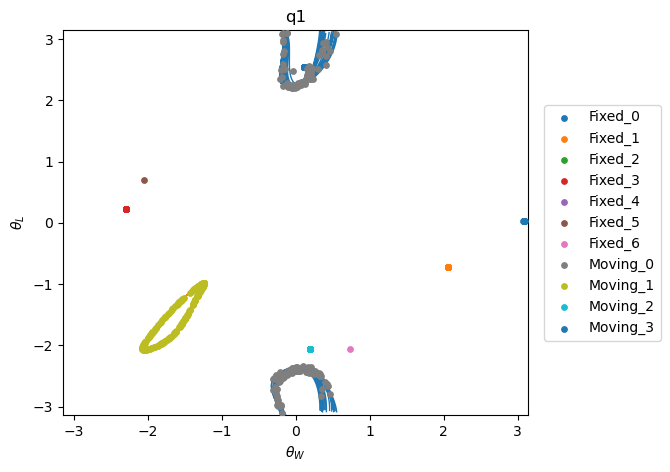

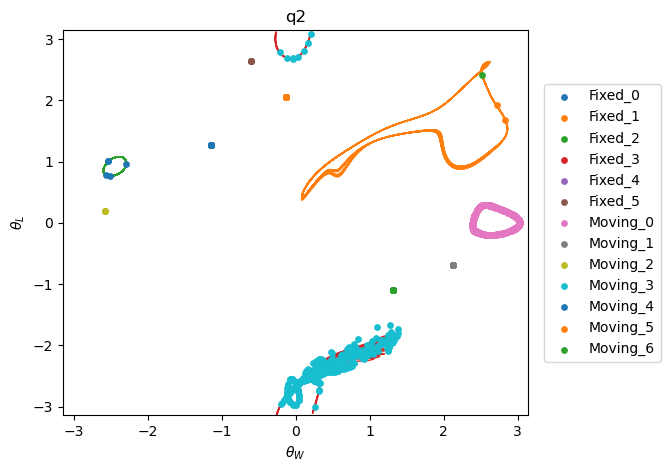

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_28534/2196108859.py:139: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


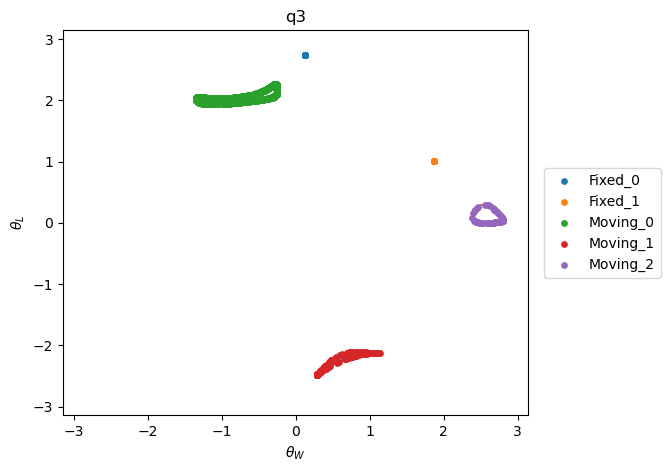

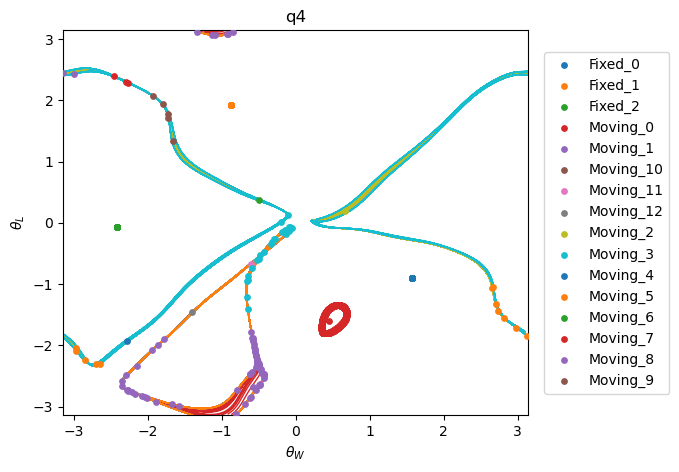

In [176]:
folder = "../Results_new/All_fightbouts_ordered_perfight_quarters_corrected"

results_q1 = analyze_endpoints_file(f"{folder}/Endpoints_q1.csv")
results_q2 = analyze_endpoints_file(f"{folder}/Endpoints_q2.csv")
results_q3 = analyze_endpoints_file(f"{folder}/Endpoints_q3.csv")
results_q4 = analyze_endpoints_file(f"{folder}/Endpoints_q4.csv")

df_q1 = classify_fixed_and_loops(results_q1,eps_loop=0.5,min_samples_loop=1,force_tol=1e-3)
df_q2 = classify_fixed_and_loops(results_q2,eps_loop=0.5,min_samples_loop=1,force_tol=1e-3)
df_q3 = classify_fixed_and_loops(results_q3,eps_loop=0.5,min_samples_loop=1,force_tol=1e-3)
df_q4 = classify_fixed_and_loops(results_q4,eps_loop=0.35,min_samples_loop=1,force_tol=1e-3)
df_q1.to_csv(f"{folder}/Classified_q1.csv", index=False)
df_q2.to_csv(f"{folder}/Classified_q2.csv", index=False)
df_q3.to_csv(f"{folder}/Classified_q3.csv", index=False)
df_q4.to_csv(f"{folder}/Classified_q4.csv", index=False)

def break_periodic_jumps(thetaW, thetaL, jump=np.pi):
    thetaW = np.asarray(thetaW).copy()
    thetaL = np.asarray(thetaL).copy()

    dW = np.abs(np.diff(thetaW))
    dL = np.abs(np.diff(thetaL))
    jumps = (dW > jump) | (dL > jump)

    thetaW_plot = thetaW.astype(float)
    thetaL_plot = thetaL.astype(float)

    thetaW_plot[1:][jumps] = np.nan
    thetaL_plot[1:][jumps] = np.nan

    return thetaW_plot, thetaL_plot


#### Q1
fig, ax = plt.subplots(figsize=(6, 5))

for name, g in df_q1.groupby("attractor_id"):
    ax.scatter(
        g["theta1_final"],
        g["theta2_final"],
        s=15,
        cmap="viridis",
        label=name,
        zorder=3)

#sc = ax.scatter(wrap_pi(df_q1["theta1_final"]),wrap_pi(df_q1["theta2_final"]),c=df_q1["d_final"],s=15,cmap="viridis",zorder=3)

#cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label(r"$D_{pp}$ final")

data = np.load(f"{folder}/endpoint_3000_trajs_q1.npz")
last_trajs = data["last_trajs"]
startpoints = data["startpoints"]

for target in [ "Moving_0","Moving_1", "Moving_2", "Moving_4","Moving_5", "Moving_6"]:
    g = df_q1[df_q1["attractor_id"] == target]
    if len(g) == 0:
        continue

    row = g.iloc[0]
    sp = np.array([row["d0"], row["theta10"], row["theta20"]])
    idx = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

    traj = last_trajs[idx]
    traj = traj[np.isfinite(traj[:, 0])]

    thetaW = wrap_pi(traj[:, 1])
    thetaL = wrap_pi(traj[:, 2])

    thetaW_plot, thetaL_plot = break_periodic_jumps(thetaW, thetaL, jump=np.pi)

    ax.plot(thetaW_plot,thetaL_plot,linewidth=1,
    )

ax.set_xlabel(r"$\theta_W$")
ax.set_ylabel(r"$\theta_L$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_title("q1")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
#fig.savefig(f"{folder}/Clustered_endpoints_q1.png",bbox_inches="tight")
plt.show()


#### Q2
fig, ax = plt.subplots(figsize=(6, 5))

for name, g in df_q2.groupby("attractor_id"):
    ax.scatter(
        g["theta1_final"],
        g["theta2_final"],
        s=15,
        label=name,
        zorder=3
    )

#sc = ax.scatter(wrap_pi(df_q2["theta1_final"]),wrap_pi(df_q2["theta2_final"]),c=df_q2["d_final"],s=15,cmap="viridis",zorder=3)

#cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label(r"$D_{pp}$ final")

data = np.load(f"{folder}/endpoint_3000_trajs_q2.npz")
last_trajs = data["last_trajs"]
startpoints = data["startpoints"]

for target in ["Moving_1","Moving_5","Moving_4","Moving_3","Moving_2"]:
    g = df_q2[df_q2["attractor_id"] == target]
    if len(g) == 0:
        continue

    row = g.iloc[0]
    sp = np.array([row["d0"], row["theta10"], row["theta20"]])
    idx = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

    traj = last_trajs[idx]
    traj = traj[np.isfinite(traj[:, 0])]

    thetaW = wrap_pi(traj[:, 1])
    thetaL = wrap_pi(traj[:, 2])

    thetaW_plot, thetaL_plot = break_periodic_jumps(thetaW, thetaL, jump=np.pi)

    ax.plot(thetaW_plot,thetaL_plot,linewidth=1,
    )

ax.set_xlabel(r"$\theta_W$")
ax.set_ylabel(r"$\theta_L$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_title("q2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

#fig.savefig(f"{folder}/Clustered_endpoints_q2.png",bbox_inches="tight")
plt.show()

#### Q3
fig, ax = plt.subplots(figsize=(6, 5))
for name, g in df_q3.groupby("attractor_id"):
    ax.scatter(
        g["theta1_final"],
        g["theta2_final"],
        s=15,
        cmap="viridis",
        label=name,
        zorder=3)

#sc = ax.scatter(wrap_pi(df_q3["theta1_final"]),wrap_pi(df_q3["theta2_final"]),c=df_q3["d_final"],s=15,cmap="viridis",zorder=3)

#cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label(r"$D_{pp}$ final")

data = np.load(f"{folder}/endpoint_3000_trajs_q3.npz")
last_trajs = data["last_trajs"]
startpoints = data["startpoints"]

for target in ["Moving_1","Moving_2","Moving_3"]:
    g = df_q3[df_q3["attractor_id"] == target]
    if len(g) == 0:
        continue

    row = g.iloc[0]
    sp = np.array([row["d0"], row["theta10"], row["theta20"]])
    idx = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

    traj = last_trajs[idx]
    traj = traj[np.isfinite(traj[:, 0])]
    thetaW = wrap_pi(traj[:, 1])
    thetaL = wrap_pi(traj[:, 2])

    thetaW_plot, thetaL_plot = break_periodic_jumps(thetaW, thetaL, jump=np.pi)

    ax.plot(thetaW_plot,thetaL_plot,linewidth=1,
    )



ax.set_xlabel(r"$\theta_W$")
ax.set_ylabel(r"$\theta_L$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_title("q3")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
#fig.savefig(f"{folder}/Clustered_endpoints_q3.png",bbox_inches="tight")
plt.show()

#### Q4
fig, ax = plt.subplots(figsize=(6, 5))

for name, g in df_q4.groupby("attractor_id"):
    ax.scatter(
        g["theta1_final"],
        g["theta2_final"],
        s=15,
        label=name,
        zorder=3
    )

#sc = ax.scatter(wrap_pi(df_q4["theta1_final"]),wrap_pi(df_q4["theta2_final"]),c=df_q4["d_final"],s=15,cmap="viridis",zorder=3)

#cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label(r"$D_{pp}$ final")

data = np.load(f"{folder}/endpoint_3000_trajs_q4.npz")
last_trajs = data["last_trajs"]
startpoints = data["startpoints"]


for target in ["Moving_1","Moving_5","Moving_2","Moving_3","Moving_4","Moving_6","Moving_7","Moving_8","Moving_9","Moving_10","Moving_11","Moving_12"]:
    g = df_q4[df_q4["attractor_id"] == target]
    if len(g) == 0:
        continue

    row = g.iloc[0]
    sp = np.array([row["d0"], row["theta10"], row["theta20"]])
    idx = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

    traj = last_trajs[idx]
    traj = traj[np.isfinite(traj[:, 0])]

    thetaW = wrap_pi(traj[:, 1])
    thetaL = wrap_pi(traj[:, 2])

    thetaW_plot, thetaL_plot = break_periodic_jumps(thetaW, thetaL, jump=np.pi)

    ax.plot(thetaW_plot,thetaL_plot,linewidth=1,
    )

ax.set_xlabel(r"$\theta_W$")
ax.set_ylabel(r"$\theta_L$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_title("q4")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

#fig.savefig(f"{folder}/Clustered_endpoints_q2.png",bbox_inches="tight")

plt.show()

In [216]:
q4_attractor_labels = (
    df_q2_all_labeled
    .groupby("attractor_id")["manoeuvre_label"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

q4_attractor_labels

,attractor_id,manoeuvre_label
0,Fixed_0,display-like
1,Fixed_1,winner attack-like
2,Fixed_2,display-like
3,Fixed_3,loser attack-like
4,Fixed_4,loser approach-like
5,Fixed_5,winner approach-like
6,Moving_0,loser attack-like moving attractor
7,Moving_1,loser attack-like moving attractor
8,Moving_2,loser attack-like moving attractor
9,Moving_3,winner attack-like moving attractor


In [208]:
def classify_point(D, thetaW, thetaL, d_close=5, d_far=15, Fixed =True):
    thetaW = wrap_pi(thetaW)
    thetaL = wrap_pi(thetaL)

    W = abs(thetaW)
    L = abs(thetaL)

    side_region = (
        (W > np.pi/4) and (W < 3*np.pi/4) and
        (L > np.pi/4) and (L < 3*np.pi/4)
    )

    if D < d_close:
        if side_region and (thetaW * thetaL > 0):
            return "circling-like"
        elif abs(wrap_pi(thetaL - thetaW)) < np.pi/4 and Fixed == False:
            return "mutual attack"

        elif abs(wrap_pi(thetaL + thetaW)) < np.pi/4 and Fixed == False:
            return "mutual attack"
        elif W < np.pi/4 and L > np.pi/4:
            return "winner attack-like"

        elif L < np.pi/4 and W > np.pi/4:
            return "loser attack-like"

        elif W < np.pi/4 and L < np.pi/4:
            return "mutual attack/direct towards"


        elif side_region and (thetaW * thetaL < 0):
            return "display-like"


        elif W >= 3*np.pi/4 and L >= 3*np.pi/4:
            return "direct-away/disengaged"

        else:
            return "unclear close"

    elif D < d_far:
        if W < np.pi/4 and L > np.pi/4:
            return "winner approach-like"

        elif L < np.pi/4 and W > np.pi/4:
            return "loser approach-like"

        elif W < np.pi/4 and L < np.pi/4:
            return "mutual approach-like"
        
        elif abs(wrap_pi(thetaL - thetaW)) < np.pi/4 and Fixed == False:
            return "mutual attack"
        
        elif abs(wrap_pi(thetaL + thetaW)) < np.pi/4 and Fixed == False:
            return "mutual attack"

        else:
            return "unclear middle-distance"

    else:
        return "far/unclear"
    
def fixed_into_manouvres(df, d_close=5, d_far=15):
    labels = []
    df_fixed = df[df["attractor_type"] == "fixed"].copy()

    for i, row in df_fixed.iterrows():
        label = classify_point(
            row["d_final"],
            row["theta1_final"],
            row["theta2_final"],
            d_close=d_close,
            d_far=d_far
        , Fixed = True)
        labels.append(label)

    df_fixed["manoeuvre_label"] = labels
    return df_fixed

def classify_moving_traj(traj, last_n=3000, d_close=5, d_far=15):
    traj = traj[np.isfinite(traj[:, 0])]
    traj = traj[-last_n:]

    labels = []

    for D, thetaW, thetaL in zip(traj[:, 0], traj[:, 1], traj[:, 2]):
        labels.append(
            classify_point(D, thetaW, thetaL, d_close=d_close, d_far=d_far, Fixed =False)
        )

    fractions = pd.Series(labels).value_counts(normalize=True)

    main_label = fractions.idxmax()
    main_fraction = fractions.max()

    if main_fraction < 0.35:
        final_label = "mixed/reciprocal moving attractor"
    else:
        final_label = main_label + " moving attractor"

    return final_label, fractions

def moving_into_manouvre(df, last_trajs, startpoints, last_n=3000, d_close=5, d_far=15):
    df_moving = df[df["attractor_type"] == "loop_or_moving"].copy()

    labels = []
    fraction_dicts = []

    for i, row in df_moving.iterrows():

        # find the trajectory that belongs to this starting point
        sp = np.array([row["d0"], row["theta10"], row["theta20"]])
        idx = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

        traj = last_trajs[idx]

        label, fractions = classify_moving_traj(traj,last_n=last_n,d_close=d_close,d_far=d_far)

        labels.append(label)
        fraction_dicts.append(fractions.to_dict())

    df_moving["manoeuvre_label"] = labels
    df_moving["manoeuvre_fractions"] = fraction_dicts

    return df_moving


df_q1_fixed_labeled = fixed_into_manouvres(df_q1)
df_q2_fixed_labeled = fixed_into_manouvres(df_q2)
df_q3_fixed_labeled = fixed_into_manouvres(df_q3)
df_q4_fixed_labeled = fixed_into_manouvres(df_q4)

data_q1 = np.load("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/endpoint_3000_trajs_q1.npz")
last_trajs_q1 = data_q1["last_trajs"]
startpoints_q1 = data_q1["startpoints"]
data_q2 = np.load("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/endpoint_3000_trajs_q2.npz")
last_trajs_q2 = data_q2["last_trajs"]
startpoints_q2 = data_q2["startpoints"]
data_q3 = np.load("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/endpoint_3000_trajs_q3.npz")
last_trajs_q3 = data_q3["last_trajs"]
startpoints_q3 = data_q3["startpoints"]
data_q4 = np.load("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/endpoint_3000_trajs_q4.npz")
last_trajs_q4 = data_q4["last_trajs"]
startpoints_q4 = data_q4["startpoints"]

df_q1_moving_labeled = moving_into_manouvre(df_q1,last_trajs_q1,startpoints_q1,last_n=3000)
df_q1_all_labeled = pd.concat([df_q1_fixed_labeled, df_q1_moving_labeled],ignore_index=True)
df_q2_moving_labeled = moving_into_manouvre(df_q2,last_trajs_q2,startpoints_q2,last_n=3000)
df_q2_all_labeled = pd.concat([df_q2_fixed_labeled, df_q2_moving_labeled],ignore_index=True)
df_q3_moving_labeled = moving_into_manouvre(df_q3,last_trajs_q3,startpoints_q3,last_n=3000)
df_q3_all_labeled = pd.concat([df_q3_fixed_labeled, df_q3_moving_labeled],ignore_index=True)
df_q4_moving_labeled = moving_into_manouvre(df_q4,last_trajs_q4,startpoints_q4,last_n=3000)
df_q4_all_labeled = pd.concat([df_q4_fixed_labeled, df_q4_moving_labeled],ignore_index=True)


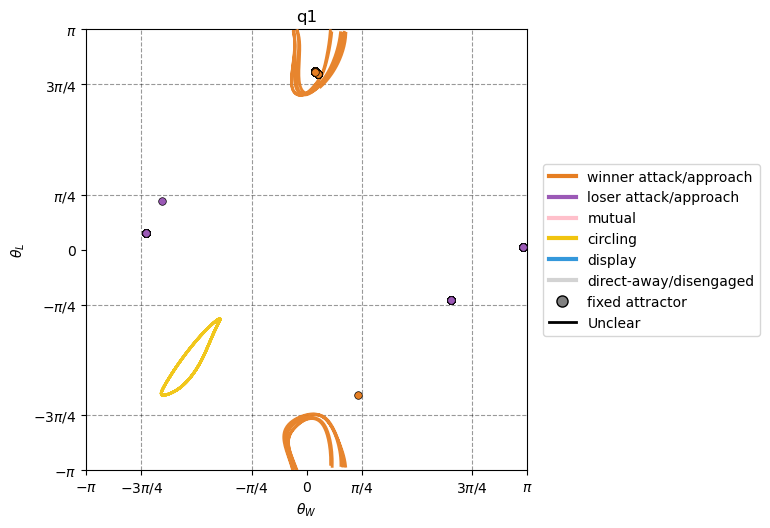

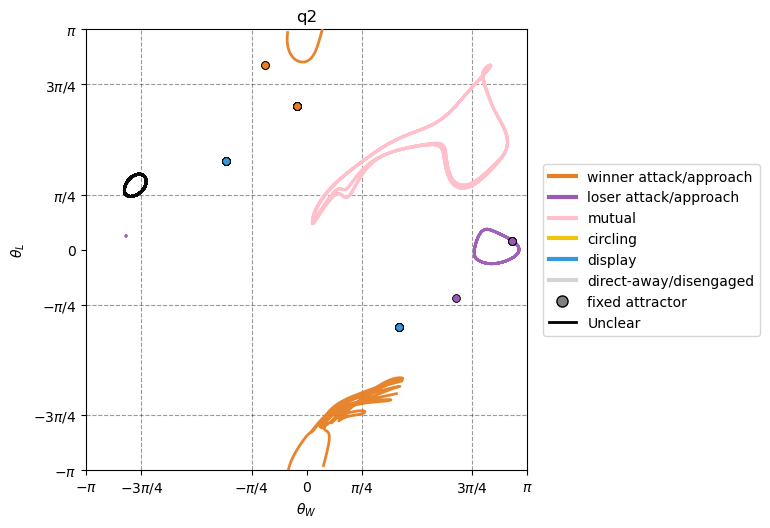

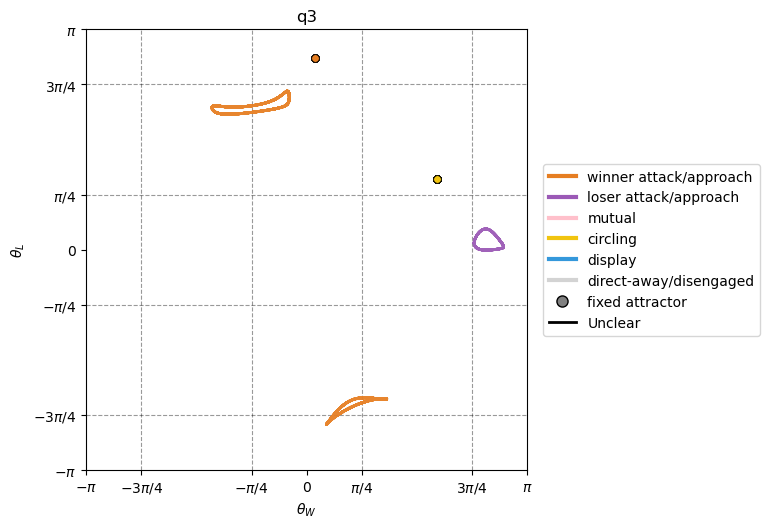

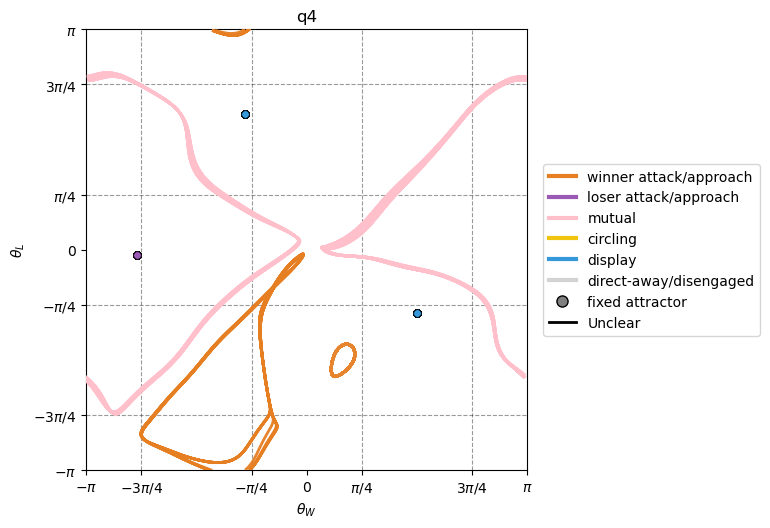

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

folder = "../Results_new/All_fightbouts_ordered_perfight_quarters_corrected"

def get_manoeuvre_color(label):
    label = str(label).lower()

    if "winner" in label:
        return "#e67e22"   # orange
    elif "loser" in label:
        return "#9b59b6"   # purple
    elif "mutual" in label:
        return "pink"
    elif "circling" in label:
        return "#f1c40f"   # yellow
    elif "display" in label:
        return "#3498db"   # blue
    elif "direct-away" in label or "disengaged" in label:
        return "lightgrey"
    else:
        return "black"


def break_periodic_jumps(thetaW, thetaL, jump=np.pi):
    thetaW = np.asarray(thetaW).copy()
    thetaL = np.asarray(thetaL).copy()

    dW = np.abs(np.diff(thetaW))
    dL = np.abs(np.diff(thetaL))
    jumps = (dW > jump) | (dL > jump)

    thetaW_plot = thetaW.astype(float)
    thetaL_plot = thetaL.astype(float)

    thetaW_plot[1:][jumps] = np.nan
    thetaL_plot[1:][jumps] = np.nan

    return thetaW_plot, thetaL_plot


def plot_quarter_attractors(df_labeled, npz_file, title, last_n=1000, savepath=None):
    fig, ax = plt.subplots(figsize=(7, 6))

    data = np.load(npz_file)
    last_trajs = data["last_trajs"]
    startpoints = data["startpoints"]

    # fixed attractors as stars
    df_fixed = df_labeled[df_labeled["attractor_type"] == "fixed"]

    for _, row in df_fixed.iterrows():
        color = get_manoeuvre_color(row["manoeuvre_label"])
        ax.scatter(
            wrap_pi(row["theta1_final"]),
            wrap_pi(row["theta2_final"]),
            marker="o",
            s=30,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            zorder=5
        )

    # moving attractors as trajectories
    df_moving = df_labeled[df_labeled["attractor_type"] == "loop_or_moving"]

    for attractor_id, g in df_moving.groupby("attractor_id"):
        row = g.iloc[0]

        sp = np.array([row["d0"], row["theta10"], row["theta20"]])
        idx = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

        traj = last_trajs[idx]
        traj = traj[np.isfinite(traj[:, 0])]
        traj = traj[-last_n:]

        thetaW = wrap_pi(traj[:, 1])
        thetaL = wrap_pi(traj[:, 2])

        thetaW_plot, thetaL_plot = break_periodic_jumps(thetaW, thetaL)

        color = get_manoeuvre_color(row["manoeuvre_label"])

        ax.plot(
            thetaW_plot,
            thetaL_plot,
            color=color,
            linewidth=2,
            alpha=0.95,
            zorder=3
        )

    # region boundary lines
    for v in [-3*np.pi/4, -np.pi/4, np.pi/4, 3*np.pi/4]:
        ax.axvline(v, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
        ax.axhline(v, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

    ## moving mutual diagonals
    #x = np.linspace(-np.pi, np.pi, 300)
    #ax.plot(x, x, color="black", linestyle=":", linewidth=1, alpha=0.7)
    #ax.plot(x, -x, color="black", linestyle=":", linewidth=1, alpha=0.7)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_aspect("equal")
    ax.set_title(title)

    ax.set_xlabel(r"$\theta_W$")
    ax.set_ylabel(r"$\theta_L$")

    ticks = [-np.pi, -np.pi/4,-3*np.pi/4, 0, np.pi/4,3*np.pi/4, np.pi]
    ticklabels = [r"$-\pi$", r"$-\pi/4$",r"$-3\pi/4$", "0",  r"$\pi/4$",r"$3\pi/4$", r"$\pi$"]

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(ticklabels)
    ax.set_yticklabels(ticklabels)

    legend_elements = [
        Line2D([0], [0], color="#e67e22", lw=3, label="winner attack/approach"),
        Line2D([0], [0], color="#9b59b6", lw=3, label="loser attack/approach"),
        Line2D([0], [0], color="pink", lw=3, label="mutual"),
        Line2D([0], [0], color="#f1c40f", lw=3, label="circling"),
        Line2D([0], [0], color="#3498db", lw=3, label="display"),
        Line2D([0], [0], color="lightgrey", lw=3, label="direct-away/disengaged"),
        Line2D([0], [0], marker="o", color="white", markeredgecolor="black",
               markerfacecolor="grey", markersize=8, linestyle="None", label="fixed attractor"),
        Line2D([0], [0], color="black", lw=2, label="Unclear")
    ]

    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", dpi=300)

    plt.show()

plot_quarter_attractors(
    df_q1_all_labeled,
    f"{folder}/endpoint_3000_trajs_q1.npz",
    "q1",
    last_n=1000,
    savepath=f"{folder}/Analysis_Figures/Manoeuvre_attractors_q1.png"
)

plot_quarter_attractors(
    df_q2_all_labeled,
    f"{folder}/endpoint_3000_trajs_q2.npz",
    "q2",
    last_n=1000,
    savepath=f"{folder}/Analysis_Figures/Manoeuvre_attractors_q2.png"
)

plot_quarter_attractors(
    df_q3_all_labeled,
    f"{folder}/endpoint_3000_trajs_q3.npz",
    "q3",
    last_n=1000,
    savepath=f"{folder}/Analysis_Figures/Manoeuvre_attractors_q3.png"
)

plot_quarter_attractors(
    df_q4_all_labeled,
    f"{folder}/endpoint_3000_trajs_q4.npz",
    "q4",
    last_n=1000,
    savepath=f"{folder}/Analysis_Figures/Manoeuvre_attractors_q4.png"
)

In [207]:
summary_counts = pd.DataFrame({
    "q1": df_q1_all_labeled["manoeuvre_label"].value_counts(),
    "q2": df_q2_all_labeled["manoeuvre_label"].value_counts(),
    "q3": df_q3_all_labeled["manoeuvre_label"].value_counts(),
    "q4": df_q4_all_labeled["manoeuvre_label"].value_counts(),
}).fillna(0).astype(int)

summary_counts

,q1,q2,q3,q4
manoeuvre_label,,,,
circling-like,0,0,23,0
circling-like moving attractor,197,0,0,0
display-like,0,325,0,593
loser approach-like,0,11,0,0
loser attack-like,497,2,0,71
loser attack-like moving attractor,6,645,81,0
mixed/reciprocal moving attractor,0,0,1,0
mutual attack moving attractor,0,3,0,29
unclear middle-distance moving attractor,0,5,0,0


In [161]:
summary_fractions = summary_counts.div(summary_counts.sum(axis=0), axis=1)
summary_fractions

,q1,q2,q3,q4
manoeuvre_label,,,,
circling-like,0.000000,0.000000,0.015551,0.000000
circling-like moving attractor,0.141007,0.000000,0.000000,0.000000
display-like,0.000000,0.235849,0.000000,0.412092
loser approach-like,0.000000,0.007983,0.000000,0.000000
loser attack-like,0.357554,0.001451,0.000000,0.049340
loser attack-like moving attractor,0.005036,0.468070,0.054767,0.000000
mixed/reciprocal moving attractor,0.000000,0.000000,0.000000,0.000695
mutual attack moving attractor,0.000000,0.002177,0.000000,0.018763
unclear middle-distance moving attractor,0.000000,0.003628,0.000000,0.000000


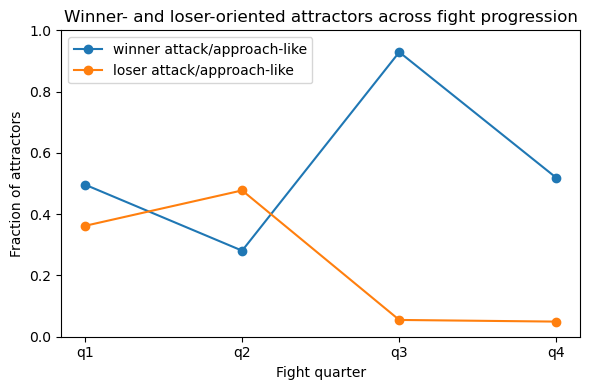

In [197]:

dfs = {
    "q1": df_q1_all_labeled,
    "q2": df_q2_all_labeled,
    "q3": df_q3_all_labeled,
    "q4": df_q4_all_labeled,
}


rows = []

for q, df in dfs.items():
    labels = df["manoeuvre_label"].astype(str)

    winner_mask = labels.str.contains("winner", case=False, na=False)
    loser_mask  = labels.str.contains("loser", case=False, na=False)

    winner_count = winner_mask.sum()
    loser_count = loser_mask.sum()
    total = len(labels)

    rows.append({
        "quarter": q,
        "winner_count": winner_count,
        "loser_count": loser_count,
        "total_attractors": total,
        "winner_fraction": winner_count / total,
        "loser_fraction": loser_count / total,
    })

winner_loser_summary = pd.DataFrame(rows)
winner_loser_summary

plt.figure(figsize=(6, 4))

plt.plot(winner_loser_summary["quarter"],winner_loser_summary["winner_fraction"],marker="o",label="winner attack/approach-like")
plt.plot(winner_loser_summary["quarter"],winner_loser_summary["loser_fraction"],marker="o",label="loser attack/approach-like")

plt.ylabel("Fraction of attractors")
plt.xlabel("Fight quarter")
plt.title("Winner- and loser-oriented attractors across fight progression")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/Analysis_Figures/Winner_vs_loser_states_perquarter.png", dpi=300)
plt.show()

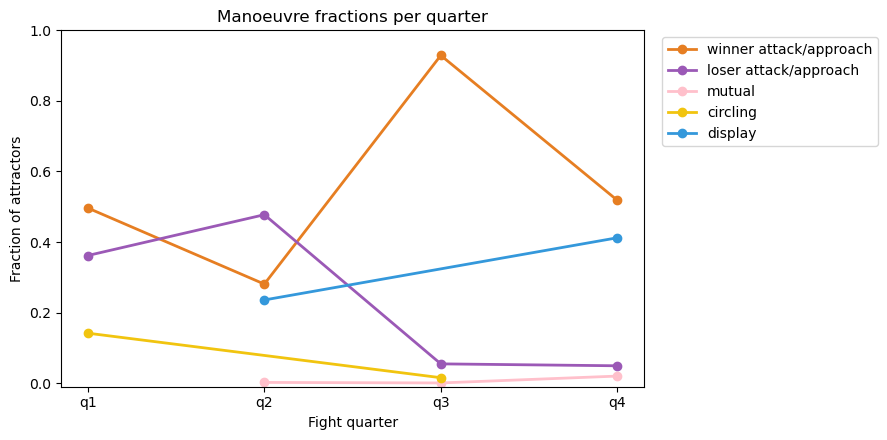

In [226]:
import pandas as pd
import matplotlib.pyplot as plt

dfs = {
    "q1": df_q1_all_labeled,
    "q2": df_q2_all_labeled,
    "q3": df_q3_all_labeled,
    "q4": df_q4_all_labeled,
}

def merge_manoeuvre_label(label):
    label = str(label).lower()

    if "winner" in label:
        return "winner attack/approach"
    elif "loser" in label:
        return "loser attack/approach"
    elif "mutual" in label or "reciprocal" in label:
        return "mutual"
    elif "circling" in label:
        return "circling"
    elif "display" in label:
        return "display"
    elif "direct-away" in label or "disengaged" in label:
        return "direct-away/disengaged"
    else:
        return "unclear"

rows = []

for q, df in dfs.items():
    merged = df["manoeuvre_label"].apply(merge_manoeuvre_label)
    total = len(merged)

    counts = merged.value_counts()

    for manoeuvre, count in counts.items():
        rows.append({
            "quarter": q,
            "manoeuvre": manoeuvre,
            "count": count,
            "fraction": count / total,
        })

summary_manoeuvres = pd.DataFrame(rows)

summary_manoeuvres

colour_map = {
    "winner attack/approach": "#e67e22",
    "loser attack/approach": "#9b59b6",
    "mutual": "pink",
    "circling": "#f1c40f",
    "display": "#3498db",
}

order = [
    "winner attack/approach",
    "loser attack/approach",
    "mutual",
    "circling",
    "display",
]

plt.figure(figsize=(9, 4.5))

for manoeuvre in order:
    sub = summary_manoeuvres[summary_manoeuvres["manoeuvre"] == manoeuvre]

    plt.plot(
        sub["quarter"],
        sub["fraction"],
        marker="o",
        linewidth=2,
        label=manoeuvre,
        color=colour_map[manoeuvre]
    )

plt.ylabel("Fraction of attractors")
plt.xlabel("Fight quarter")
plt.title("Manoeuvre fractions per quarter")
plt.ylim(-0.01, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/Analysis_Figures/manouevres_perquarter.png", dpi=300)
plt.show()

In [166]:
winner_loser_summary

,quarter,winner_count,loser_count,total_attractors,winner_fraction,loser_fraction
0,q1,690,504,1390,0.496403,0.362590
1,q2,387,658,1378,0.280842,0.477504
2,q3,1375,81,1479,0.929682,0.054767
3,q4,747,71,1439,0.519110,0.049340


In [212]:
row = df_q2_moving_labeled[
    df_q2_moving_labeled["attractor_id"] == "Moving_5"
].iloc[0]

row["manoeuvre_fractions"]

{'mutual attack': 0.5966666666666667,
 'unclear middle-distance': 0.212,
 'winner approach-like': 0.12933333333333333,
 'circling-like': 0.04533333333333334,
 'mutual approach-like': 0.016666666666666666}

attractor_id
Moving_0     652
Fixed_1      502
Fixed_0       91
Moving_1      73
Fixed_2       71
Moving_3      23
Moving_5      12
Moving_10      4
Moving_7       3
Moving_8       2
Moving_2       1
Moving_4       1
Moving_6       1
Moving_9       1
Moving_11      1
Moving_12      1
Name: count, dtype: int64
1500 1500


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_28534/1085771876.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_labels))


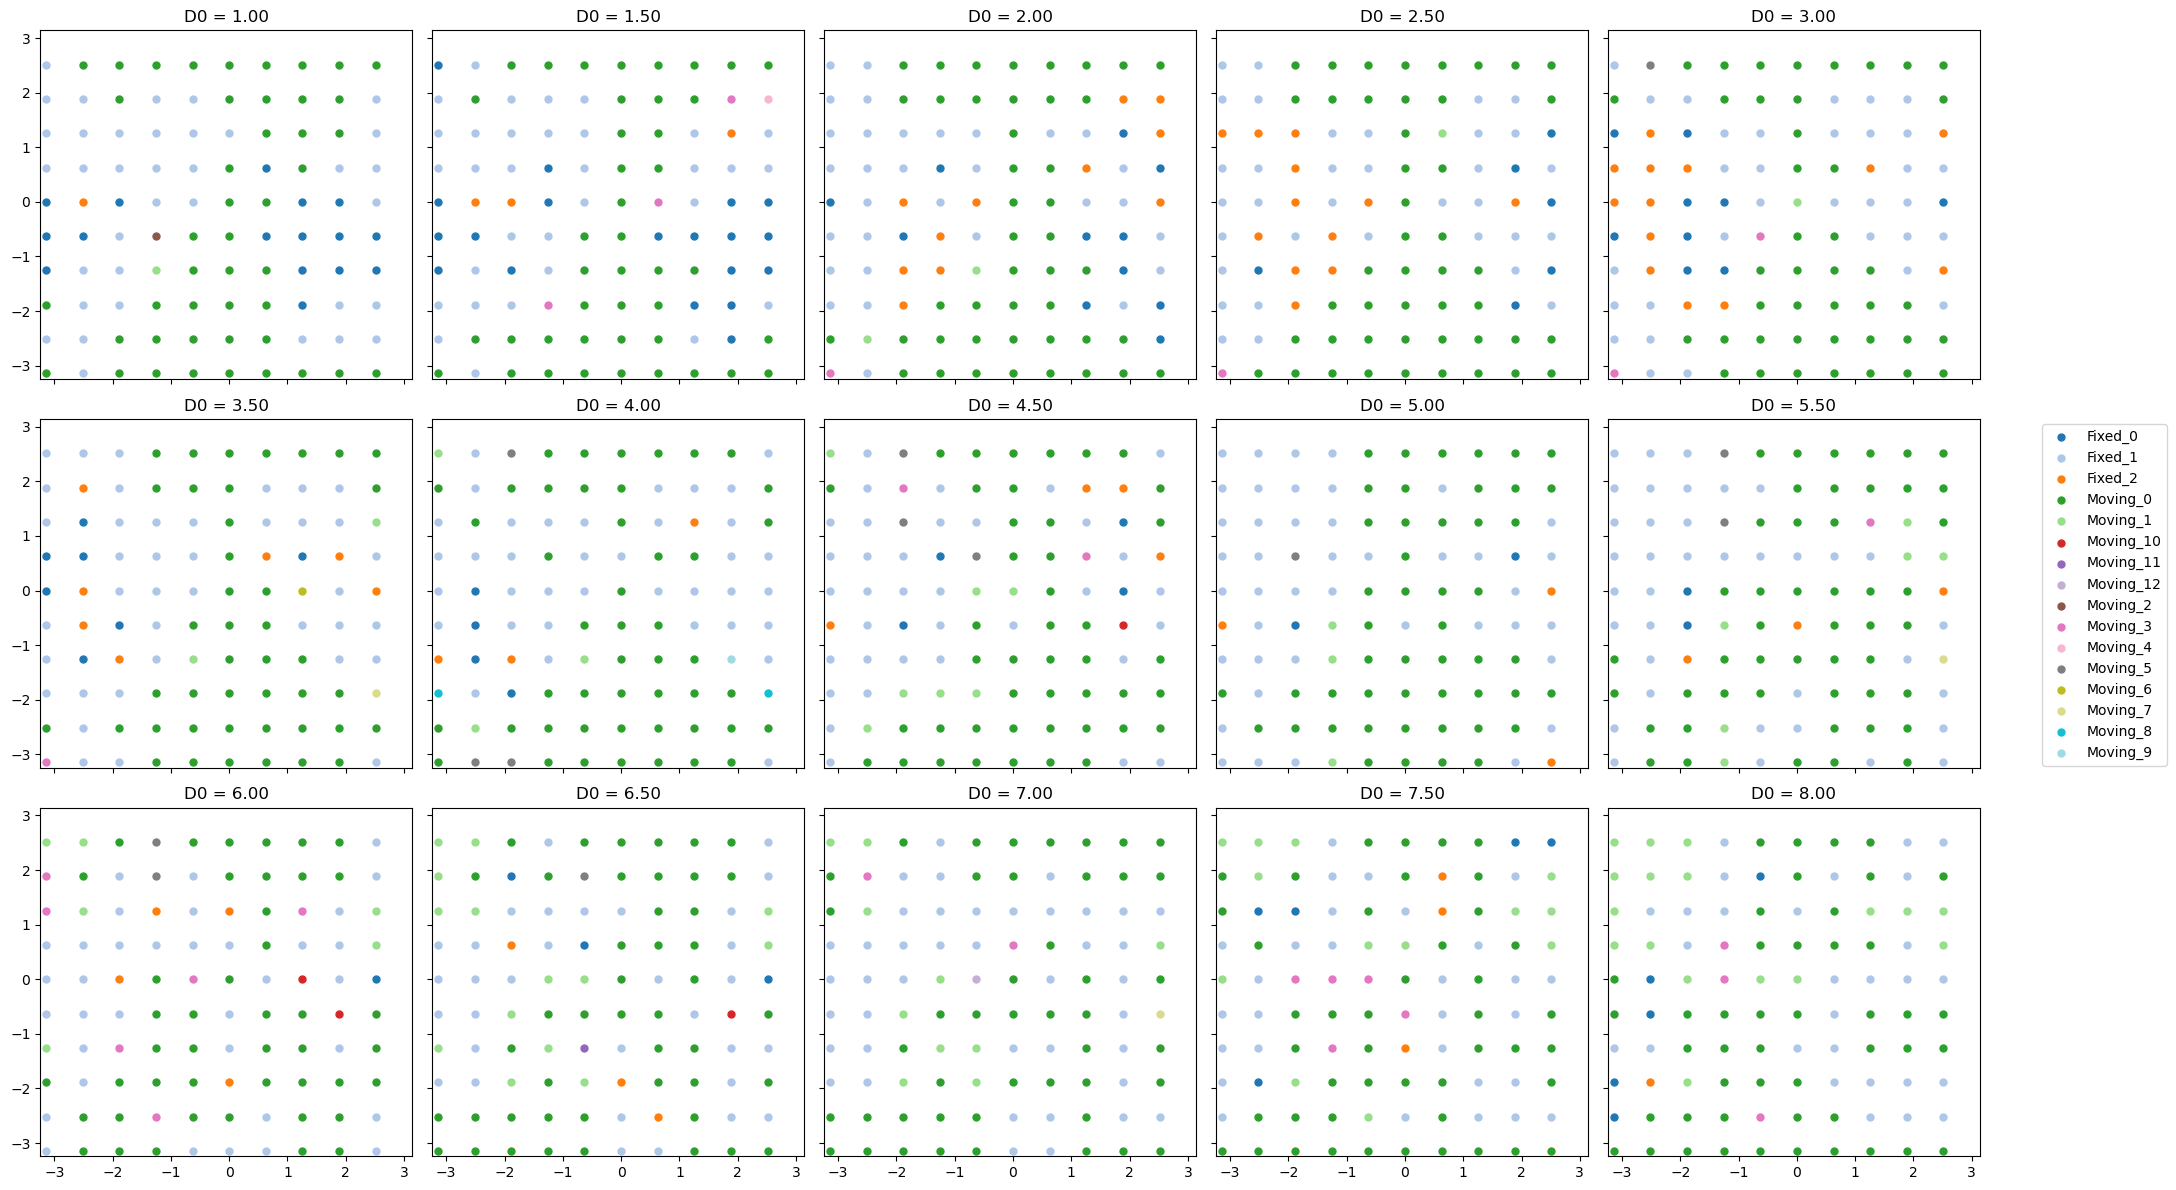

In [94]:
df = df_q4

df = df.reset_index(drop=True)

print(df["attractor_id"].value_counts())
labels = []

df_starts = df[["d0", "theta10", "theta20"]].values

for sp in startpoints:
    dist = np.linalg.norm(df_starts - sp, axis=1)
    labels.append(df.iloc[np.argmin(dist)]["attractor_id"])

labels = np.array(labels)
print(len(labels), len(startpoints))

unique_labels = np.unique(labels)
cmap = cm.get_cmap("tab20", len(unique_labels))
color_dict = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

label_to_int = {lab: i for i, lab in enumerate(unique_labels)}
colors = np.array([label_to_int[l] for l in labels])

D_values = np.unique(np.round(startpoints[:, 0], 6))

ncols = 5
nrows = int(np.ceil(len(D_values) / ncols))


fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(4*ncols, 4*nrows),
    sharex=True,
    sharey=True
)

axs = axs.ravel()

for ax, D0 in zip(axs, D_values):

    mask_D = np.isclose(startpoints[:,0], D0)

    for lab in unique_labels:

        mask = mask_D & (labels == lab)

        ax.scatter(
            startpoints[mask,1],
            startpoints[mask,2],
            color=color_dict[lab],
            s=25,
            label=lab
        )

    ax.set_title(f"D0 = {D0:.2f}")
    ax.set_xlim((-np.pi-0.1), np.pi)
    ax.set_ylim((-np.pi-0.1), np.pi)

handles, labels_leg = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels_leg,
    bbox_to_anchor=(1.02,0.5),
    loc="center left"
)

plt.tight_layout()
plt.show()

Last half:
attractor_id
Fixed_0     774
Moving_0    564
Fixed_1     105
Fixed_3      19
Fixed_2      17
Moving_1      3

First half:
Moving_1    519
Moving_0    288
Moving_3    240
Fixed_1     156
Moving_2     83
Fixed_0      56
Moving_4     42
Fixed_5      38
Fixed_2      29
Fixed_3      27
Moving_6      8
Moving_5      6
Fixed_4       5
Moving_7      1

In [217]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

quarter = "q2"       
target = "Fixed_2"     

folder = "../Results_new/All_fightbouts_ordered_perfight_quarters_corrected"
video_folder = f"{folder}/videos"
os.makedirs(video_folder, exist_ok=True)

if quarter == "q1":
    endpoint_file = f"{folder}/Endpoints_q1.csv"
    traj_file = f"{folder}/endpoint_3000_trajs_q1.npz"
    title_window = "0--25%"
    eps_loop = 0.6      # change to the eps you used for q1 plot

elif quarter == "q2":
    endpoint_file = f"{folder}/Endpoints_q2.csv"
    traj_file = f"{folder}/endpoint_3000_trajs_q2.npz"
    title_window = "25--50%"
    eps_loop = 0.6      # change to the eps you used for q2 plot

elif quarter == "q3":
    endpoint_file = f"{folder}/Endpoints_q3.csv"
    traj_file = f"{folder}/endpoint_3000_trajs_q3.npz"
    title_window = "50--75%"
    eps_loop = 0.6      # change to the eps you used for q3 plot

elif quarter == "q4":
    endpoint_file = f"{folder}/Endpoints_q4.csv"
    traj_file = f"{folder}/endpoint_3000_trajs_q4.npz"
    title_window = "75--100%"
    eps_loop = 0.35
df = classify_fixed_and_loops(
    analyze_endpoints_file(endpoint_file),
    eps_loop=eps_loop,
    min_samples_loop=1,
    force_tol=1e-3
).reset_index(drop=True)

data = np.load(traj_file)
last_trajs = data["last_trajs"]
startpoints = data["startpoints"]

print(df["attractor_id"].value_counts())
print("target rows:", len(df[df["attractor_id"] == target]))  
row = df[df["attractor_id"] == target].iloc[0]
sp = np.array([row["d0"], row["theta10"], row["theta20"]])
best = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

traj = last_trajs[best]
valid = np.isfinite(traj[:, 0])
traj = traj[valid]

D = traj[:, 0]
theta1 = wrap_pi(traj[:, 1])
theta2 = wrap_pi(traj[:, 2])

step = 5
D = D[::step]
theta1 = theta1[::step]
theta2 = theta2[::step]
fig, ax = plt.subplots(figsize=(6, 6))

def update(i):
    draw_two_agents(
        ax,
        D[i],
        theta1[i],
        theta2[i],
        title=f"{target} {quarter} | frame {i}/{len(D)-1}\n"
              f"D={D[i]:.2f}, θW={theta1[i]:.2f}, θL={theta2[i]:.2f}"
    )

ani = FuncAnimation(fig, update, frames=len(D), interval=50)
out = f"../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/videos/{target}_{quarter}_config.mp4"
ani.save(out, writer=FFMpegWriter(fps=20, bitrate=1800))
plt.close(fig)
HTML(ani.to_jshtml())
#print("saved:", out)

attractor_id
Moving_0    620
Moving_3    320
Fixed_0     255
Fixed_2      70
Fixed_1      62
Moving_1     22
Fixed_4      11
Fixed_5       5
Moving_4      5
Moving_2      3
Fixed_3       2
Moving_5      2
Moving_6      1
Name: count, dtype: int64
target rows: 70


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_18464/2591739803.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(th1, th2, th1_dt, levels=[0], colors='blue', linewidths=2,label = "th1")
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_18464/2591739803.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(th1, th2, th2_dt, levels=[0], colors='red', linewidths=2,label = "th2")
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_18464/2591739803.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


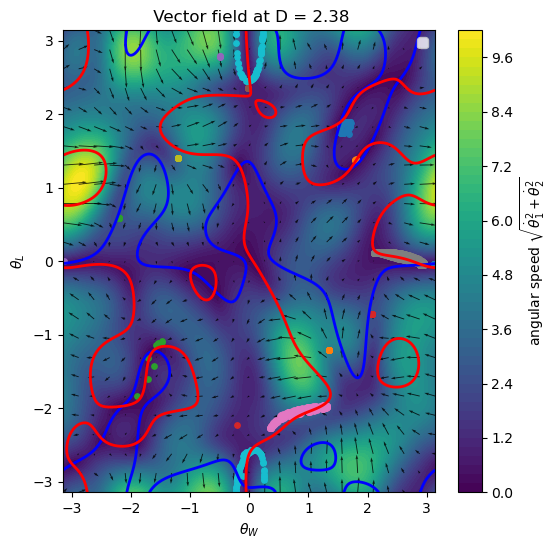

In [113]:
D_value = 2.38
theta_vals = np.linspace(-np.pi, np.pi, 300)
th1, th2 = np.meshgrid(theta_vals, theta_vals)

d_dt, th1_dt, th2_dt = F(
    np.full(th1.size, D_value),
    th1.ravel(),
    th2.ravel(),S_first
)

th1_dt = th1_dt.reshape(th1.shape)
th2_dt = th2_dt.reshape(th2.shape)
speed_ang = np.sqrt(th1_dt**2 + th2_dt**2)

theta_vals_q = np.linspace(-np.pi, np.pi, 25)
th1_q, th2_q = np.meshgrid(theta_vals_q, theta_vals_q)

_, th1_dt_q, th2_dt_q = F(np.full(th1_q.size, D_value),th1_q.ravel(),th2_q.ravel(),S_first)
plt.figure(figsize=(6,6))
plt.contour(th1, th2, th1_dt, levels=[0], colors='blue', linewidths=2,label = "th1")
plt.contour(th1, th2, th2_dt, levels=[0], colors='red', linewidths=2,label = "th2")
plt.contourf(th1, th2, speed_ang,levels=50,cmap="viridis")
plt.colorbar(label=r"angular speed $\sqrt{\dot\theta_1^2+\dot\theta_2^2}$")
plt.quiver(th1_q, th2_q, th1_dt_q, th2_dt_q, color='black', alpha=0.8)
#mask = np.isclose(clustered_all[:, 0], D_value)
#endpoints_D = clustered_all[mask]
#plt.scatter(endpoints_D[:,1], endpoints_D[:,2], c='k', s=30, label='stable endpoints')
for name, g in df_first.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15)
#plt.scatter(-0.804024   ,   2.026886, c='k', s=30)
plt.xlabel(r'$\theta_W$')
plt.ylabel(r'$\theta_L$')
plt.title(f' Vector field at D = {D_value}')
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.legend()
plt.show()

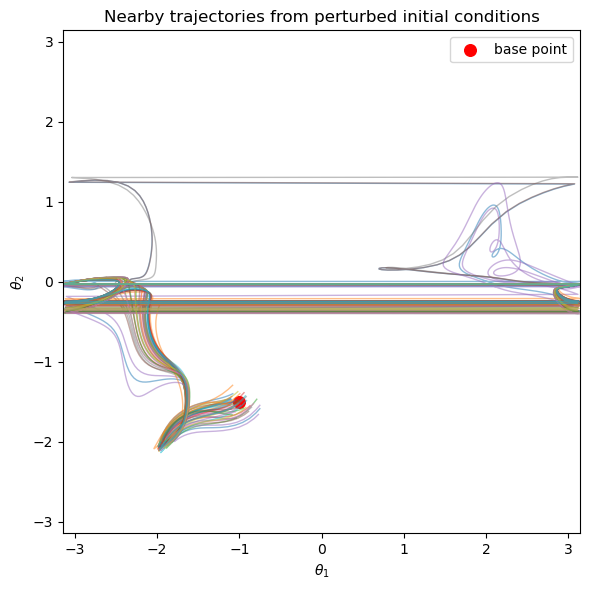

In [25]:
from scipy.integrate import solve_ivp

def rhs(t,x):
    D, th1, th2 = x

    dDdt, dth1dt, dth2dt = F(
        np.array([D]),
        np.array([wrap_pi(th1)]),
        np.array([wrap_pi(th2)]),
        S_first
    )

    return [
        dDdt[0],
        dth1dt[0],
        dth2dt[0]
    ]

base = np.array([2,-1,-1.5])

eps = 0.1
n_trajs = 40

initials = []
for k in range(n_trajs):
    x0 = base + eps * np.random.randn(3)
    x0[0] = np.clip(x0[0], 0.5, 10)   # keep D positive
    x0[1] = wrap_pi(x0[1])
    x0[2] = wrap_pi(x0[2])
    initials.append(x0)

fig, ax = plt.subplots(figsize=(6,6))

for x0 in initials:
    sol = solve_ivp(
        rhs,
        [0, 10],
        x0,
        max_step=0.02,
        rtol=1e-6,
        atol=1e-8
    )

    th1_traj = wrap_pi(sol.y[1])
    th2_traj = wrap_pi(sol.y[2])

    ax.plot(th1_traj, th2_traj, alpha=0.5, linewidth=1)

ax.scatter(base[1], base[2], c="red", s=70, label="base point")

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_title("Nearby trajectories from perturbed initial conditions")
ax.legend()
plt.tight_layout()
plt.show()

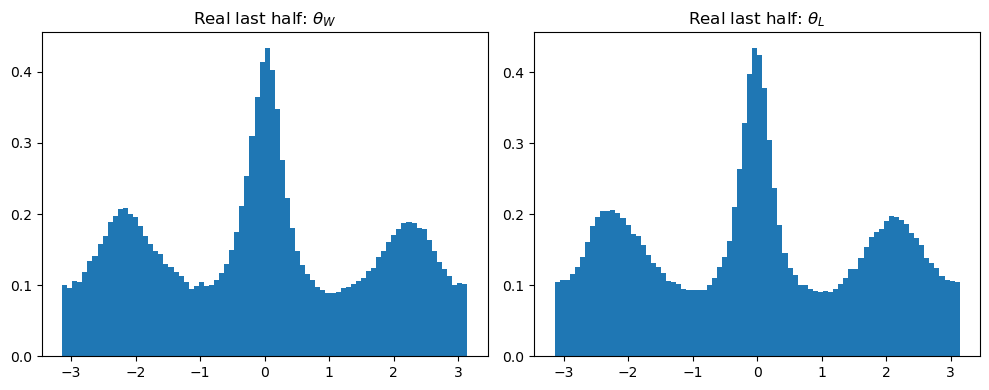

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(wrap_pi(X_last[:,1]), bins=80, density=True)
plt.title(r"Real last half: $\theta_W$")

plt.subplot(1,2,2)
plt.hist(wrap_pi(X_last[:,2]), bins=80, density=True)
plt.title(r"Real last half: $\theta_L$")

plt.tight_layout()
plt.show()

In [429]:
fixed3 = classified_first[classified_first["attractor_id"] == "Moving_2"]
print(f"Number of points in Fixed_3: {len(fixed3)}")
print(fixed3[["d_final", "theta1_final", "theta2_final", "force_norm"]])

Number of points in Fixed_3: 22
      d_final  theta1_final  theta2_final  force_norm
339  1.928560     -1.781142     -1.509221    1.955678
340  1.936429     -1.715914     -1.431018    1.907687
345  2.622622     -1.598836     -1.635202    2.100453
346  2.558851     -1.507873     -1.515610    2.522180
423  2.135026     -1.891577     -1.737192    2.449504
424  2.251632     -1.882721     -1.769884    2.599065
431  2.372845     -1.852359     -1.779439    2.594278
432  2.528111     -1.490262     -1.480836    2.591694
433  2.478535     -1.472609     -1.434420    2.628481
439  2.245178     -1.484668     -1.315179    2.404004
508  2.090317     -1.888581     -1.716049    2.366302
516  2.229726     -1.885966     -1.765738    2.580679
517  2.575521     -1.520753     -1.537356    2.461849
518  2.454656     -1.467505     -1.415297    2.624754
526  1.992540     -1.860772     -1.639954    2.160302
603  2.112458     -1.890601     -1.727272    2.408713
604  2.612075     -1.567144     -1.600727    2.232

1.546457, 1.397839,1.985024,  2.930836, moving; 3.8, 1.35, 2.0

In [220]:
def summarize_function(df,exp_id,half):
    summary = (df.groupby(["attractor_type", "attractor_id"]).agg(
            n_points=("attractor_id", "size"),
            d_mean=("d_final", "mean"),
            theta1_mean=("theta1_final", "mean"),
            theta2_mean=("theta2_final", "mean"),
            mean_force=("force_norm", "mean"),
            mean_steps=("step_used", "mean"),

            d_std=("d_final", "std"),
            theta1_std=("theta1_final", "std"),
            theta2_std=("theta2_final", "std"),).reset_index())

    summary["attractor_fraction"] = (summary["n_points"] / len(df))
    summary["exp_id"] = exp_id
    summary["half"] = half

    return summary


all_sumaries = []
exp_runagain = [7,8,13]
exp_ids = [2,3,5,10,12,15,18,19,20]


for exp_id in exp_ids:
    first_path = f"../Results_new/Exp_{exp_id}_fight2/Classified_first.csv"
    last_path  = f"../Results_new/Exp_{exp_id}_fight2/Classified_last.csv"
    df_first = pd.read_csv(first_path)
    df_last = pd.read_csv(last_path)

    summary_first = summarize_function(df_first,exp_id,"first")
    summary_last = summarize_function(df_last,exp_id,"last")
    all_sumaries.append(summary_first)
    all_sumaries.append(summary_last)

for exp_id1 in exp_runagain:
    first_path = f"../Results/Exp_{exp_id1}_fight1/Classified_first.csv"
    last_path  = f"../Results/Exp_{exp_id1}_fight1/Classified_last.csv"
    df_first = pd.read_csv(first_path)
    df_last = pd.read_csv(last_path)

    summary_first = summarize_function(df_first,exp_id1,"first")
    summary_last = summarize_function(df_last,exp_id1,"last")
    all_sumaries.append(summary_first)
    all_sumaries.append(summary_last)

complete_summary = pd.concat(all_sumaries, ignore_index=True)
complete_summary.to_csv("../Results_new/complete_attractor_summary.csv",index = False)

In [221]:
summary_df = pd.read_csv("../Results_new/complete_attractor_summ.csv")
print(summary_df.head(3))


  attractor_type attractor_id  n_points    d_mean  theta1_mean  theta2_mean  \
0          fixed      Fixed_0      1408  2.509541     2.770609     0.089730   
1          fixed      Fixed_1         8  7.673016    -2.809160     0.139837   
2          fixed      Fixed_2        35  4.708411    -2.728564     0.058398   

   mean_force   mean_steps     d_std  theta1_std  theta2_std  \
0    0.000648  1772.529830  0.000102    0.000041    0.000004   
1    0.000870  1702.500000  0.000964    0.000045    0.000058   
2    0.000576   530.857143  0.000138    0.000028    0.000006   

   attractor_fraction  exp_id   half  
0            0.939920       2  first  
1            0.005340       2  first  
2            0.023364       2  first  


In [223]:
dominant_first = summary_df[(summary_df["attractor_fraction"]>0.) &(complete_summary["attractor_type"] == "loop_or_moving")& (summary_df["half"]=="first")]
dominant_last = summary_df[(summary_df["attractor_fraction"]>0.) & (complete_summary["attractor_type"] == "loop_or_moving")&(summary_df["half"]=="last")]
print(dominant_first.shape,dominant_last.shape)

(42, 14) (31, 14)


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/3671552369.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dominant_first = summary_df[(summary_df["attractor_fraction"]>0.) &(complete_summary["attractor_type"] == "loop_or_moving")& (summary_df["half"]=="first")]
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/3671552369.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dominant_last = summary_df[(summary_df["attractor_fraction"]>0.) & (complete_summary["attractor_type"] == "loop_or_moving")&(summary_df["half"]=="last")]


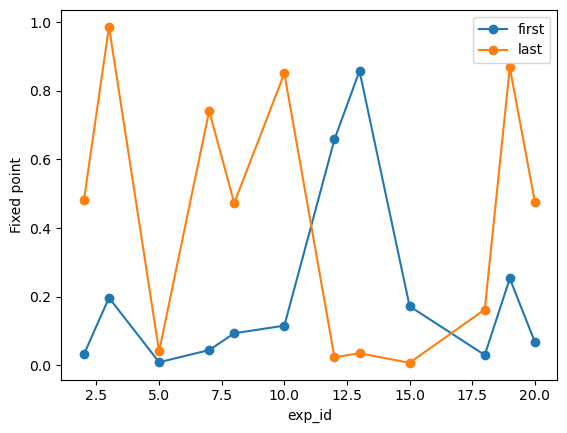

In [208]:
df = summary_df[(summary_df["attractor_fraction"] > 0.0) &(summary_df["attractor_type"] == "loop_or_moving")]
first = (df[df["half"] == "first"].groupby("exp_id")["attractor_fraction"].sum().sort_index())
last = (df[df["half"] == "last"].groupby("exp_id")["attractor_fraction"].sum().sort_index())
plt.plot(first.index, first.values, label="first",marker = "o")
plt.plot(last.index, last.values, label="last",marker = "o")
plt.xlabel("exp_id")
plt.ylabel("Fixed point")
plt.legend()
plt.show()

total first = 110
total last  = 102


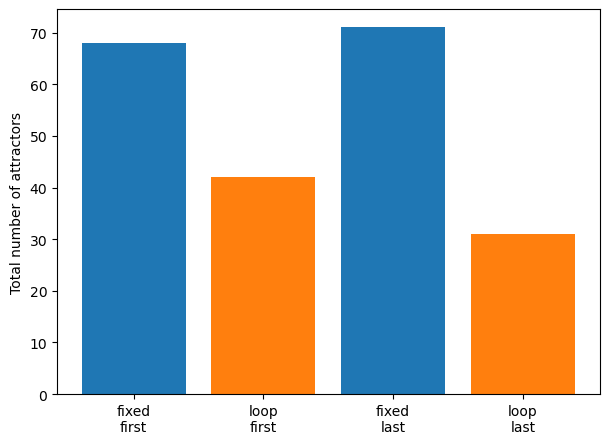

In [236]:
counts = (
    summary_df
    .groupby(["half", "attractor_type"])
    .size()
)

fixed_first = counts.get(("first", "fixed"), 0)
loop_first  = counts.get(("first", "loop_or_moving"), 0)

fixed_last = counts.get(("last", "fixed"), 0)
loop_last  = counts.get(("last", "loop_or_moving"), 0)

plt.figure(figsize=(7,5))

plt.bar(
    ["fixed\nfirst", "loop\nfirst",
     "fixed\nlast", "loop\nlast"],
    
    [fixed_first, loop_first,
     fixed_last, loop_last],

    color=[
        "tab:blue",
        "tab:orange",
        "tab:blue",
        "tab:orange"
    ]
)

plt.ylabel("Total number of attractors")

plt.savefig("../Results_new/Figures/Total_num_attractors_hist.png")

print("total first =", fixed_first + loop_first)
print("total last  =", fixed_last + loop_last)

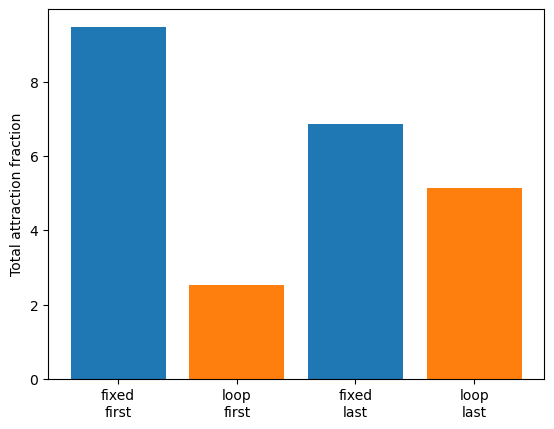

In [237]:
fixed = summary_df[summary_df["attractor_type"]=="fixed"]
loops = summary_df[summary_df["attractor_type"]=="loop_or_moving"]

fixed_first = fixed[fixed["half"]=="first"]["attractor_fraction"].sum()
fixed_last  = fixed[fixed["half"]=="last"]["attractor_fraction"].sum()

loop_first = loops[loops["half"]=="first"]["attractor_fraction"].sum()
loop_last  = loops[loops["half"]=="last"]["attractor_fraction"].sum()

labels = ["fixed\nfirst", "loop\nfirst",
          "fixed\nlast", "loop\nlast"]

values = [
    fixed_first,
    loop_first,
    fixed_last,
    loop_last
]

colors = [
    "tab:blue",   # fixed
    "tab:orange", # loop
    "tab:blue",   # fixed
    "tab:orange"  # loop
]

plt.bar(labels, values, color=colors)

plt.ylabel("Total attraction fraction")

plt.savefig("../Results_new/Figures/Total_attractors_frac_hist.png")


In [217]:
summary_df.groupby(["half","attractor_type"])["attractor_fraction"].mean()

half   attractor_type
first  fixed             0.139329
       loop_or_moving    0.060134
last   fixed             0.096541
       loop_or_moving    0.165988
Name: attractor_fraction, dtype: float64

In [238]:
def Simulation_deterministic(S,x0,dt,N_steps,force_tol,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else jnp.clip(x[0], 0.0, 20.0))
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs)

X_first: (520025, 3)
X_last: (520033, 3)
time_idx_first: (520025,)
time_idx_last: (520033,)
segments first: 1580
segments last: 2843
Measurement noise trace: -0.032397061586380005.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.032397061586380005). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 0.64821386  0.00326848 -0.01195333]
 [ 0.00326848  1.0075434   0.27053592]
 [-0.01195333  0.27053592  1.038522  ]]
Measurement noise tensor:
 [[-9.4361687e-03 -9.0120542e-05  5.9764880e-05]
 [-9.0120549e-05 -1.1390285e-02 -2.5268351e-03]
 [ 5.9764880e-05 -2.5268351e-03 -1.1570606e-02]]
Force estimated information: 104988.5390625
Force: estimated normalized mean squared error (sampling only): 0.0131633710116148
Force model:
 +26.44 (±0.5773) b₀ -17.6 (±0.1725) b₁ +10.68 (±0.06104) b₂ +0.1116 (±0.03642) b₃ -5.991 (±0.08165) b₄ +0.0148 (±0.08745) b₅ +1.74 (±0.089) b₆ +0.9267 (±0.09579) b₇ -0.3617 (±0.1024) b₈ -0.4856 (±0.

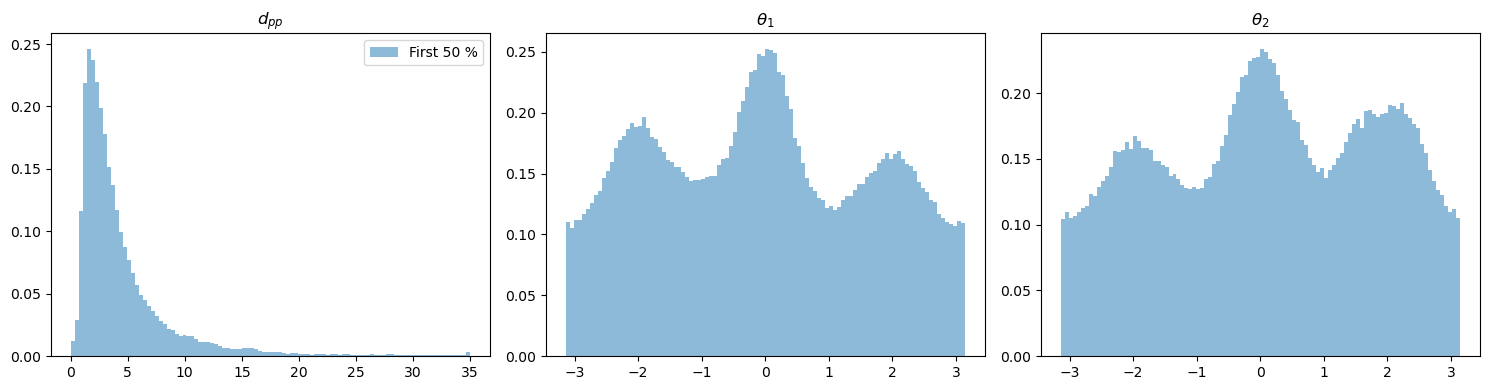

0.09676490998531885


X_q1: (260010, 3)
X_q2: (260015, 3)
X_q3: (260014, 3)
X_q4: (260019, 3)
lam_common: [0.7804654 2.4657896 9.029227 ]
Measurement noise trace: -0.029326193034648895.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.029326193034648895). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 0.70490533 -0.00808859  0.00529258]
 [-0.00808859  0.8094519   0.1732522 ]
 [ 0.00529258  0.1732522   0.9107529 ]]
Measurement noise tensor:
 [[-9.0893582e-03 -6.3348532e-05  4.5515831e-06]
 [-6.3348547e-05 -1.0026588e-02 -1.9469589e-03]
 [ 4.5515858e-06 -1.9469592e-03 -1.0210245e-02]]
Force estimated information: 52762.8984375
Force: estimated normalized mean squared error (sampling only): 0.027253776788711548
Force model:
 +28.07 (±0.9818) b₀ -18.3 (±0.2683) b₁ +11.19 (±0.09739) b₂ -1.284 (±0.05226) b₃ -6.242 (±0.1345) b₄ -0.2791 (±0.1301) b₅ +0.5488 (±0.1279) b₆ +0.01182 (±0.1323) b₇ +0.1882 (±0.138) b₈ -0.2752 (±0.1378) b₉ +0.9104 

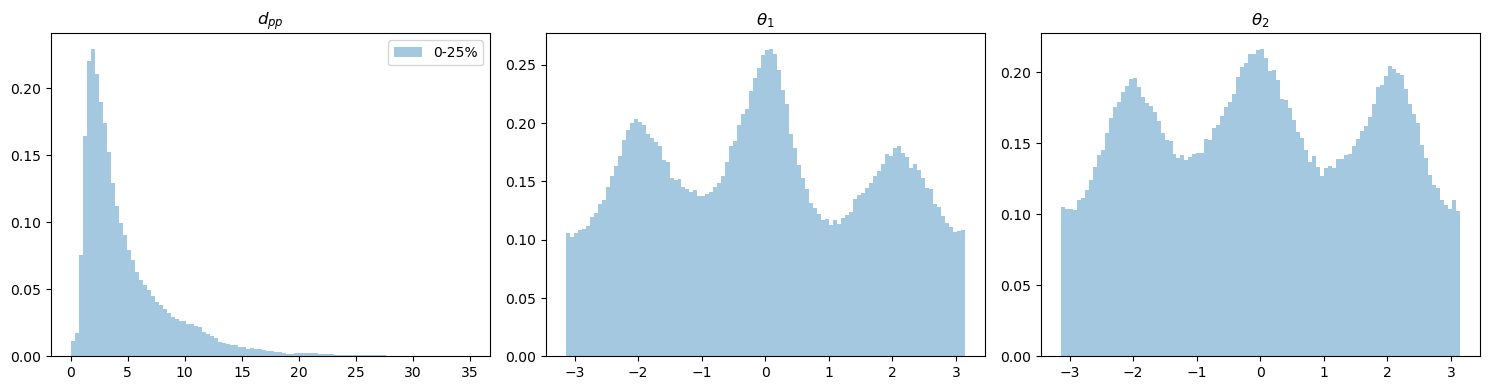

JS q1: 0.08849817414597456


In [2]:
tracking_folder = os.path.dirname(path_2)
winner_df = make_winner_df(tracking_folder)

X_q1_list = []
X_q2_list = []
X_q3_list = []
X_q4_list = []

segment_ids_q1_list = []
segment_ids_q2_list = []
segment_ids_q3_list = []
segment_ids_q4_list = []

time_idx_q1_list = []
time_idx_q2_list = []
time_idx_q3_list = []
time_idx_q4_list = []

seg_offset_q1 = 0
seg_offset_q2 = 0
seg_offset_q3 = 0
seg_offset_q4 = 0

time_offset_q1 = 0
time_offset_q2 = 0
time_offset_q3 = 0
time_offset_q4 = 0

for exp in experiments:
    path = paths[exp]

    X_coordinates, fightbout, exp_id = prepare_data(path, 0, True)

    winner_row = winner_df[winner_df["EXP_id"] == exp_id]
    id_winner = int(winner_row["winnerIdx"].iloc[0])

    if id_winner == 1:
        X_coordinates = X_coordinates[:, [1, 0], :, :]

    dpp, theta1, theta2 = calculate_variables(X_coordinates)

    # IMPORTANT: build segmented data on full fightbout first
    X_seg, time_idx_seg, segment_ids_seg, seg_ranges = Build_segmented_data(
        dpp, theta1, theta2
    )

    n = len(X_seg)
    q1_end = n // 4
    q2_end = n // 2
    q3_end = 3 * n // 4

    X_seg_q1 = X_seg[:q1_end]
    time_idx_seg_q1 = time_idx_seg[:q1_end] - time_idx_seg[:q1_end][0]
    segment_ids_seg_q1 = segment_ids_seg[:q1_end]

    X_seg_q2 = X_seg[q1_end:q2_end]
    time_idx_seg_q2 = time_idx_seg[q1_end:q2_end] - time_idx_seg[q1_end:q2_end][0]
    segment_ids_seg_q2 = segment_ids_seg[q1_end:q2_end]

    X_seg_q3 = X_seg[q2_end:q3_end]
    time_idx_seg_q3 = time_idx_seg[q2_end:q3_end] - time_idx_seg[q2_end:q3_end][0]
    segment_ids_seg_q3 = segment_ids_seg[q2_end:q3_end]

    X_seg_q4 = X_seg[q3_end:]
    time_idx_seg_q4 = time_idx_seg[q3_end:] - time_idx_seg[q3_end:][0]
    segment_ids_seg_q4 = segment_ids_seg[q3_end:]

    # q1
    X_q1_list.append(X_seg_q1)
    segment_ids_q1_list.append(segment_ids_seg_q1 + seg_offset_q1)
    time_idx_q1_list.append(time_idx_seg_q1 + time_offset_q1)

    seg_offset_q1 += segment_ids_seg_q1.max() + 1
    time_offset_q1 += time_idx_seg_q1.max() + 1

    # q2
    X_q2_list.append(X_seg_q2)
    segment_ids_q2_list.append(segment_ids_seg_q2 + seg_offset_q2)
    time_idx_q2_list.append(time_idx_seg_q2 + time_offset_q2)

    seg_offset_q2 += segment_ids_seg_q2.max() + 1
    time_offset_q2 += time_idx_seg_q2.max() + 1

    # q3
    X_q3_list.append(X_seg_q3)
    segment_ids_q3_list.append(segment_ids_seg_q3 + seg_offset_q3)
    time_idx_q3_list.append(time_idx_seg_q3 + time_offset_q3)

    seg_offset_q3 += segment_ids_seg_q3.max() + 1
    time_offset_q3 += time_idx_seg_q3.max() + 1

    # q4
    X_q4_list.append(X_seg_q4)
    segment_ids_q4_list.append(segment_ids_seg_q4 + seg_offset_q4)
    time_idx_q4_list.append(time_idx_seg_q4 + time_offset_q4)

    seg_offset_q4 += segment_ids_seg_q4.max() + 1
    time_offset_q4 += time_idx_seg_q4.max() + 1


X_q1 = np.vstack(X_q1_list)
segment_ids_q1 = np.concatenate(segment_ids_q1_list)
time_idx_q1 = np.concatenate(time_idx_q1_list)

X_q2 = np.vstack(X_q2_list)
segment_ids_q2 = np.concatenate(segment_ids_q2_list)
time_idx_q2 = np.concatenate(time_idx_q2_list)

X_q3 = np.vstack(X_q3_list)
segment_ids_q3 = np.concatenate(segment_ids_q3_list)
time_idx_q3 = np.concatenate(time_idx_q3_list)

X_q4 = np.vstack(X_q4_list)
segment_ids_q4 = np.concatenate(segment_ids_q4_list)
time_idx_q4 = np.concatenate(time_idx_q4_list)



X_all_quarters = np.vstack([X_q1, X_q2, X_q3, X_q4])
dpp_all = X_all_quarters[:, 0]

q01, q50, q95 = np.percentile(dpp_all, [1, 50, 95])
lam_common = jnp.array([q01, q50, q95])

print("X_q1:", X_q1.shape)
print("X_q2:", X_q2.shape)
print("X_q3:", X_q3.shape)
print("X_q4:", X_q4.shape)
print("lam_common:", lam_common)

#base_dir = os.environ.get("SLURM_SUBMIT_DIR", os.getcwd())
##outdir = os.path.join(base_dir, "Results", "All_fightbouts_ordered_perfight_quarters")
#os.makedirs(outdir, exist_ok=True)

i_q1 = np.random.randint(0,len(X_q1))
i_q2 = np.random.randint(0,len(X_q2))
i_q3= np.random.randint(0,len(X_q3))
i_q4 = np.random.randint(0,len(X_q4))

x0_q1 = X_q1[i_q1]
x0_q2 =X_q2[i_q2]
x0_q3 = X_q3[i_q3]
x0_q4 = X_q4[i_q4]

key = random.PRNGKey(0)

S_q1, descriptor = Run_Force_inference(X_q1, time_idx_q1, K=3, M=4, lam=lam_common)
#S_q2, descriptor = Run_Force_inference(X_q2, time_idx_q2, K=3, M=4, lam=lam_common)
#S_q3, descriptor = Run_Force_inference(X_q3, time_idx_q3, K=3, M=4, lam=lam_common)
#S_q4, descriptor = Run_Force_inference(X_q4, time_idx_q4, K=3, M=4, lam=lam_common)

traj_sim_q1, key = Simulation(S_q1, x0_q1, dt=0.01, N_steps=500000, key=key)
#traj_sim_q2, key = Simulation(S_q2, x0_q2, dt=0.01, N_steps=500000, key=key)
#traj_sim_q3, key = Simulation(S_q3, x0_q3, dt=0.01, N_steps=500000, key=key)
#traj_sim_q4, key = Simulation(S_q4, x0_q4, dt=0.01, N_steps=500000, key=key)

traj_sim_q1_np = np.array(traj_sim_q1)
#traj_sim_q2_np = np.array(traj_sim_q2)
#traj_sim_q3_np = np.array(traj_sim_q3)
#traj_sim_q4_np = np.array(traj_sim_q4)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].hist(traj_sim_q1_np[:, 0], alpha=0.4, density=True, label="0-25%", bins=100)
#axs[0].hist(traj_sim_q2_np[:, 0], alpha=0.4, density=True, label="25-50%", bins=100)
#axs[0].hist(traj_sim_q3_np[:, 0], alpha=0.4, density=True, label="50-75%", bins=100)
#axs[0].hist(traj_sim_q4_np[:, 0], alpha=0.4, density=True, label="75-100%", bins=100)
axs[0].legend()
axs[0].set_title(r"$d_{pp}$")

axs[1].hist(wrap_pi(traj_sim_q1_np[:, 1]), alpha=0.4, density=True, bins=100)
#axs[1].hist(wrap_pi(traj_sim_q2_np[:, 1]), alpha=0.4, density=True, bins=100)
#axs[1].hist(wrap_pi(traj_sim_q3_np[:, 1]), alpha=0.4, density=True, bins=100)
#axs[1].hist(wrap_pi(traj_sim_q4_np[:, 1]), alpha=0.4, density=True, bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(wrap_pi(traj_sim_q1_np[:, 2]), alpha=0.4, density=True, bins=100)
#axs[2].hist(wrap_pi(traj_sim_q2_np[:, 2]), alpha=0.4, density=True, bins=100)
##axs[2].hist(wrap_pi(traj_sim_q3_np[:, 2]), alpha=0.4, density=True, bins=100)
#axs[2].hist(wrap_pi(traj_sim_q4_np[:, 2]), alpha=0.4, density=True, bins=100)
axs[2].set_title(r"$\theta_2$")

plt.tight_layout()
#fig_path = os.path.join(outdir, "stochastic_simulation_distributions_quarters.png")
#plt.savefig(fig_path, dpi=300)
plt.show()

js_q1 = average_js_score(X_q1[:,0], wrap_pi(X_q1[:,1]), wrap_pi(X_q1[:,2]), traj_sim_q1_np)
#js_q2 = average_js_score(X_q2[:,0], wrap_pi(X_q2[:,1]), wrap_pi(X_q2[:,2]), traj_sim_q2_np)
##js_q3 = average_js_score(X_q3[:,0], wrap_pi(X_q3[:,1]), wrap_pi(X_q3[:,2]), traj_sim_q3_np)
#js_q4 = average_js_score(X_q4[:,0], wrap_pi(X_q4[:,1]), wrap_pi(X_q4[:,2]), traj_sim_q4_np)

print("JS q1:", js_q1)
#print("JS q2:", js_q2)
#print("JS q3:", js_q3)
#print("JS q4:", js_q4)

In [3]:
assert len(X_first) == len(time_idx_first)
assert len(X_last) == len(time_idx_last)

assert len(X_q1) == len(time_idx_q1)
assert len(X_q2) == len(time_idx_q2)
assert len(X_q3) == len(time_idx_q3)
assert len(X_q4) == len(time_idx_q4)

print("halves lambda:", lam_common)
print("first/last shapes:", X_first.shape, X_last.shape)
print("quarter shapes:", X_q1.shape, X_q2.shape, X_q3.shape, X_q4.shape)

print("first/last segments:", len(np.unique(segment_ids_first)), len(np.unique(segment_ids_last)))
print("quarter segments:",
      len(np.unique(segment_ids_q1)),
      len(np.unique(segment_ids_q2)),
      len(np.unique(segment_ids_q3)),
      len(np.unique(segment_ids_q4)))

halves lambda: [0.7804654 2.4657896 9.029227 ]
first/last shapes: (520025, 3) (520033, 3)
quarter shapes: (260010, 3) (260015, 3) (260014, 3) (260019, 3)
first/last segments: 1580 2843
quarter segments: 568 1023 1240 1614


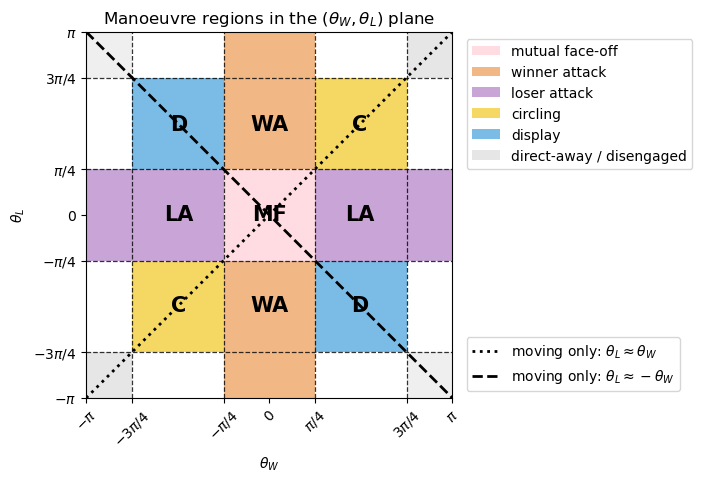

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

fig, ax = plt.subplots(figsize=(7, 7))

p4 = np.pi / 4
p34 = 3 * np.pi / 4

# colours
col_mf = "pink"
col_c  = "#f1c40f"   # yellow
col_la = "#9b59b6"   # purple
col_wa = "#e67e22"   # orange
col_d  = "#3498db"   # blue
col_away = "lightgrey"

# axis limits
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)

# -------------------------
# Main manoeuvre regions
# -------------------------

# mutual face-off / mutual attack: center
ax.add_patch(Rectangle((-p4, -p4), 2*p4, 2*p4,
                       facecolor=col_mf, alpha=0.55, edgecolor="none"))

# winner attack: thetaW front, thetaL outside front
ax.add_patch(Rectangle((-p4, p4), 2*p4, np.pi-p4,
                       facecolor=col_wa, alpha=0.55, edgecolor="none"))
ax.add_patch(Rectangle((-p4, -np.pi), 2*p4, np.pi-p4,
                       facecolor=col_wa, alpha=0.55, edgecolor="none"))

# loser attack: thetaL front, thetaW outside front
ax.add_patch(Rectangle((-np.pi, -p4), np.pi-p4, 2*p4,
                       facecolor=col_la, alpha=0.55, edgecolor="none"))
ax.add_patch(Rectangle((p4, -p4), np.pi-p4, 2*p4,
                       facecolor=col_la, alpha=0.55, edgecolor="none"))

# side-side regions only: pi/4 < |theta| < 3pi/4
# same sign = circling in your current code
ax.add_patch(Rectangle((p4, p4), p34-p4, p34-p4,
                       facecolor=col_c, alpha=0.65, edgecolor="none"))
ax.add_patch(Rectangle((-p34, -p34), p34-p4, p34-p4,
                       facecolor=col_c, alpha=0.65, edgecolor="none"))

# opposite sign = display
ax.add_patch(Rectangle((-p34, p4), p34-p4, p34-p4,
                       facecolor=col_d, alpha=0.65, edgecolor="none"))
ax.add_patch(Rectangle((p4, -p34), p34-p4, p34-p4,
                       facecolor=col_d, alpha=0.65, edgecolor="none"))

# direct-away / disengaged: both away
ax.add_patch(Rectangle((p34, p34), np.pi-p34, np.pi-p34,
                       facecolor=col_away, alpha=0.55, edgecolor="none"))
ax.add_patch(Rectangle((-np.pi, -np.pi), np.pi-p34, np.pi-p34,
                       facecolor=col_away, alpha=0.55, edgecolor="none"))
ax.add_patch(Rectangle((-np.pi, p34), np.pi-p34, np.pi-p34,
                       facecolor=col_away, alpha=0.35, edgecolor="none"))
ax.add_patch(Rectangle((p34, -np.pi), np.pi-p34, np.pi-p34,
                       facecolor=col_away, alpha=0.35, edgecolor="none"))

# -------------------------
# Moving-only reciprocal diagonals
# -------------------------
x = np.linspace(-np.pi, np.pi, 600)

ax.plot(x, x, color="black", linestyle=":", linewidth=2,
        label=r"moving only: $\theta_L \approx \theta_W$")

ax.plot(x, -x, color="black", linestyle="--", linewidth=2,
        label=r"moving only: $\theta_L \approx -\theta_W$")

# boundary lines
for v in [-p34, -p4, p4, p34]:
    ax.axvline(v, color="black", linestyle="--", linewidth=0.9, alpha=0.8)
    ax.axhline(v, color="black", linestyle="--", linewidth=0.9, alpha=0.8)

# ticks
ticks = [-np.pi, -3*np.pi/4, -np.pi/4, 0,
         np.pi/4, 3*np.pi/4, np.pi]

ticklabels = [
    r"$-\pi$", r"$-3\pi/4$",  r"$-\pi/4$", "0",
    r"$\pi/4$", r"$3\pi/4$", r"$\pi$"
]

ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(ticklabels, rotation=45)
ax.set_yticklabels(ticklabels)

ax.set_xlabel(r"$\theta_W$")
ax.set_ylabel(r"$\theta_L$")

# text labels
ax.text(0, 0, "MF", ha="center", va="center", fontsize=15, weight="bold")
ax.text(0, 1.55, "WA", ha="center", va="center", fontsize=15, weight="bold")
ax.text(0, -1.55, "WA", ha="center", va="center", fontsize=15, weight="bold")
ax.text(-1.55, 0, "LA", ha="center", va="center", fontsize=15, weight="bold")
ax.text(1.55, 0, "LA", ha="center", va="center", fontsize=15, weight="bold")

ax.text(1.55, 1.55, "C", ha="center", va="center", fontsize=15, weight="bold")
ax.text(-1.55, -1.55, "C", ha="center", va="center", fontsize=15, weight="bold")
ax.text(-1.55, 1.55, "D", ha="center", va="center", fontsize=15, weight="bold")
ax.text(1.55, -1.55, "D", ha="center", va="center", fontsize=15, weight="bold")

# legend
legend_elements = [
    Patch(facecolor=col_mf, alpha=0.55, label="mutual face-off"),
    Patch(facecolor=col_wa, alpha=0.55, label="winner attack"),
    Patch(facecolor=col_la, alpha=0.55, label="loser attack"),
    Patch(facecolor=col_c,  alpha=0.65, label="circling"),
    Patch(facecolor=col_d,  alpha=0.65, label="display"),
    Patch(facecolor=col_away, alpha=0.55, label="direct-away / disengaged"),
]

leg1 = ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(leg1)
ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0))

ax.set_aspect("equal")
ax.set_title(r"Manoeuvre regions in the $(\theta_W,\theta_L)$ plane")

plt.tight_layout()
plt.savefig("../Results_new/All_fightbouts_ordered_perfight_quarters_corrected/Analysis_Figures/Manouvres_example.png",bbox_inches="tight")
plt.show()